In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import glob

# Get all cleaned CSV files
csv_files = glob.glob('C:\\Users\\Admin\\Documents\\amazon\\Clean_CSV\\*.csv')

# Merge all files
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

# Check merged dataset
print(df.shape)
print(df.head())

# Save merged dataset
df.to_csv(
    'amazon_india_merged_dataset.csv',
    index=False
)

print("All CSV files merged successfully!")

(791944, 36)
      transaction_id  order_date         customer_id   product_id  \
0  TXN_2015_00000001  2015-01-25  CUST_2015_00003884  PROD_000021   
1  TXN_2015_00000002  2015-05-01  CUST_2015_00011709  PROD_000055   
2  TXN_2015_00000003  2015-01-24  CUST_2015_00004782  PROD_000039   
3  TXN_2015_00000004  2015-01-28  CUST_2015_00008105  PROD_000085   
4  TXN_2015_00000005  2015-01-31  CUST_2015_00002955  PROD_000055   

                           product_name     category  subcategory     brand  \
0          Samsung Galaxy S6 16GB Black  Electronics  Smartphones   Samsung   
1          OnePlus OnePlus 2 16GB White  Electronics  Smartphones   OnePlus   
2      Samsung Galaxy Note 5 64GB Black  Electronics  Smartphones   Samsung   
3  Motorola Moto G (3rd Gen) 16GB Black  Electronics  Smartphones  Motorola   
4          OnePlus OnePlus 2 16GB White  Electronics  Smartphones   OnePlus   

   original_price_inr  discount_percent  ...  customer_rating  return_status  \
0           12361

In [ ]:
df.columns

Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name', 'category', 'subcategory', 'brand',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible',
       'product_rating', 'base_price_2015_x', 'base_price_2015_y'],
      dtype='str')

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
# 1. Install the missing renderer package directly in the notebook
import sys
!{sys.executable} -m pip install nbformat --upgrade

# 2. Import libraries and fix the renderer
import pandas as pd
import plotly.express as px
import plotly.io as pio

# This tells Plotly to use the built-in VS Code viewer
pio.renderers.default = "vscode"

# 3. Clean column names (removes hidden spaces)
df.columns = df.columns.str.strip()

print("Setup complete! Now run the next cells.")

Setup complete! Now run the next cells.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


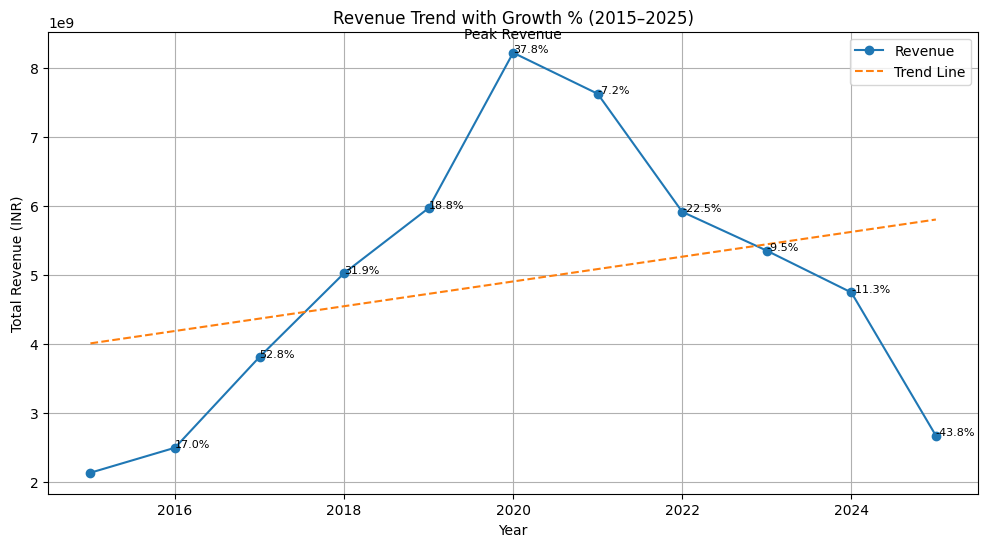

In [ ]:
# Q1: Revenue Trend with Growth % (2015–2025)
# Step 1: Revenue aggregation
revenue_trend = df.groupby('order_year')['final_amount_inr'].sum().reset_index()

# Step 2: Growth %
revenue_trend['growth_%'] = revenue_trend['final_amount_inr'].pct_change() * 100

# Step 3: Plot
plt.figure(figsize=(12,6))

# Revenue line
plt.plot(revenue_trend['order_year'],
         revenue_trend['final_amount_inr'],
         marker='o',
         label='Revenue')

# Trend line
z = np.polyfit(revenue_trend['order_year'], revenue_trend['final_amount_inr'], 1)
p = np.poly1d(z)
plt.plot(revenue_trend['order_year'],
         p(revenue_trend['order_year']),
         linestyle='--',
         label='Trend Line')

# Growth % annotations
for i in range(len(revenue_trend)):
    year = revenue_trend['order_year'][i]
    revenue = revenue_trend['final_amount_inr'][i]
    growth = revenue_trend['growth_%'][i]

    if not pd.isna(growth):
        plt.text(year, revenue, f"{growth:.1f}%", fontsize=8)

# Highlight peak year
max_row = revenue_trend.loc[revenue_trend['final_amount_inr'].idxmax()]
plt.annotate(
    "Peak Revenue",
    (max_row['order_year'], max_row['final_amount_inr']),
    textcoords="offset points",
    xytext=(0,10),
    ha='center'
)

# Labels
plt.title("Revenue Trend with Growth % (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Total Revenue (INR)")
plt.legend()
plt.grid()

plt.show()

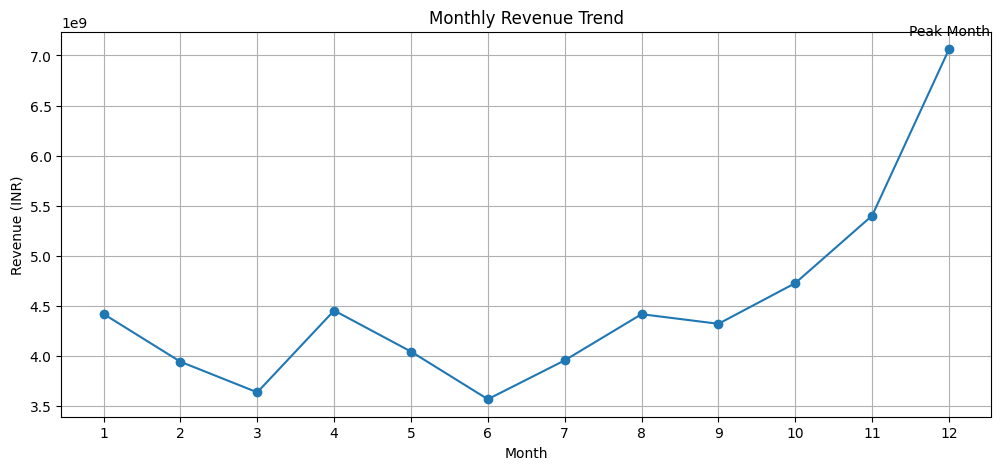

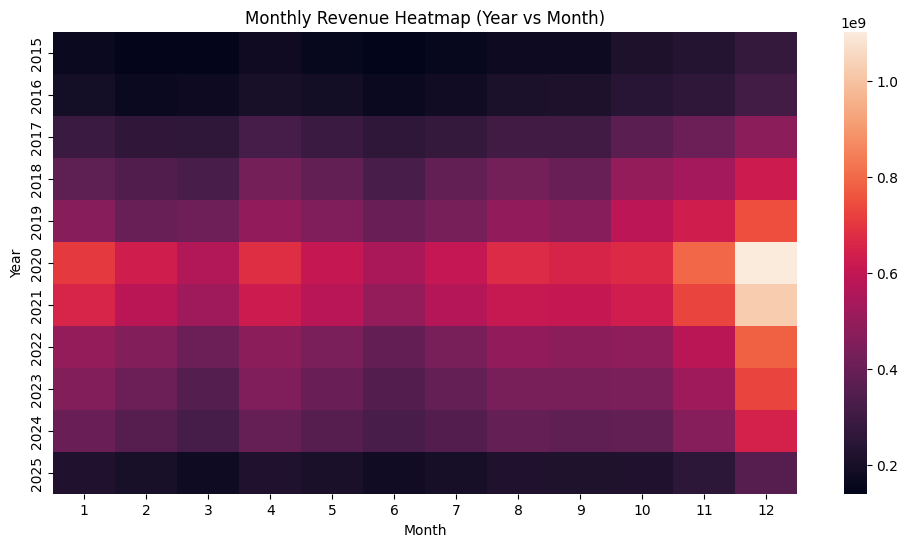


Top Categories in Peak Month:
       category  order_month  final_amount_inr
11  Electronics           12      7.061730e+09


In [ ]:
#Q2: Seasonality Analysis (Monthly Trends & Heatmap)

import seaborn as sns

monthly_trend = df.groupby('order_month')['final_amount_inr'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('order_month')

plt.figure(figsize=(12,5))
plt.plot(monthly_trend['order_month'],
         monthly_trend['final_amount_inr'],
         marker='o')

# Highlight peak month
max_row = monthly_trend.loc[monthly_trend['final_amount_inr'].idxmax()]
plt.annotate("Peak Month",
             (max_row['order_month'], max_row['final_amount_inr']),
             textcoords="offset points",
             xytext=(0,10),
             ha='center')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(range(1,13))
plt.grid()
plt.show()

# PART 2: Heatmap (Year vs Month)

heatmap_data = df.pivot_table(
    values='final_amount_inr',
    index='order_year',
    columns='order_month',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=False)

plt.title("Monthly Revenue Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

# PART 3: Category Seasonality

category_trend = df.groupby(
    ['category','order_month']
)['final_amount_inr'].sum().reset_index()

# Example: show top categories for peak month
peak_month = max_row['order_month']

top_categories = category_trend[
    category_trend['order_month'] == peak_month
].sort_values('final_amount_inr', ascending=False).head(5)

print("\nTop Categories in Peak Month:")
print(top_categories)

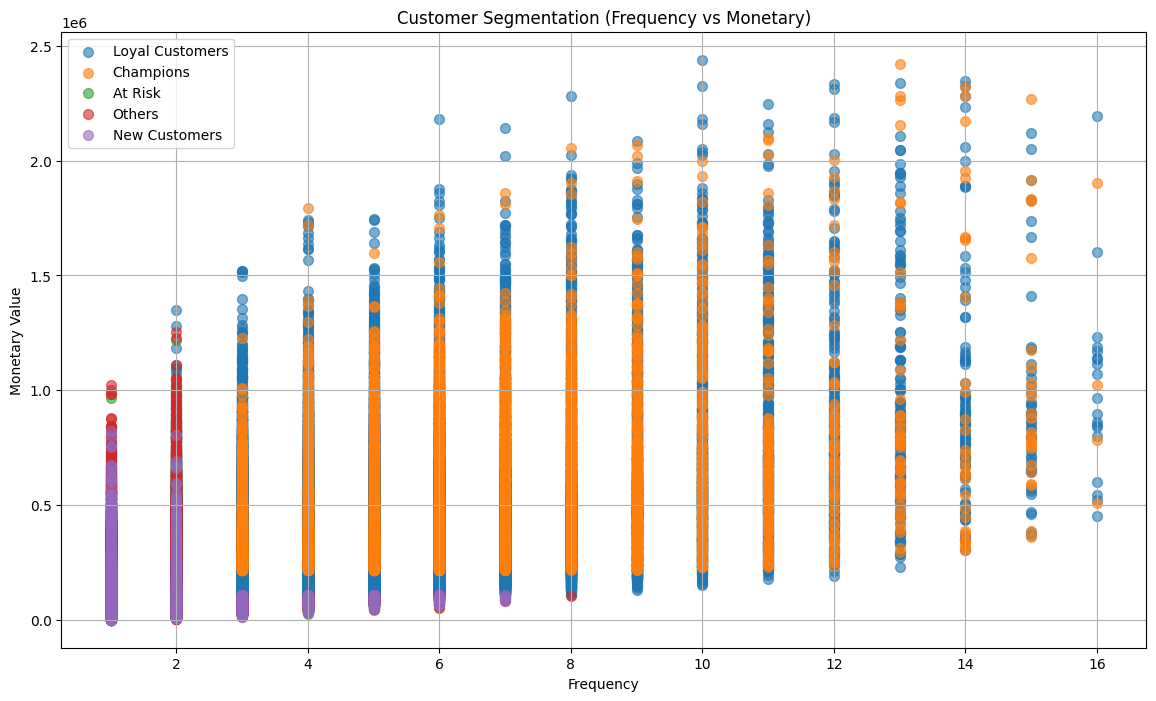


Customer Segment Distribution:
Segment
Loyal Customers    104116
Others              97849
At Risk             54385
New Customers       49358
Champions           11607
Name: count, dtype: int64


In [ ]:
#Q3: RFM Analysis & Customer Segmentation

reference_date = df['order_date'].max()

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,   
    'transaction_id': 'count',                                
    'final_amount_inr': 'sum'                                 
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# 2. SCORING (ERROR-FREE)

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(str).agg(''.join, axis=1)

# 3. CUSTOMER SEGMENTATION

def segment(row):
    if row['RFM_score'] == '444':
        return 'Champions'
    elif int(row['F_score']) >= 3 and int(row['M_score']) >= 3:
        return 'Loyal Customers'
    elif int(row['R_score']) == 4:
        return 'New Customers'
    elif int(row['R_score']) == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

# 4. SCATTER PLOT

plt.figure(figsize=(14, 8))

rfm_filtered = rfm[
    (rfm['Frequency'] <= 16) &
    (rfm['Monetary'] <= 2500000)
]

for seg in rfm_filtered['Segment'].unique():

    temp = rfm_filtered[
        rfm_filtered['Segment'] == seg
    ]

    plt.scatter(temp['Frequency'],temp['Monetary'],label=seg,alpha=0.6,s=50)

plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend()
plt.grid()
plt.show()

# 5. SEGMENT DISTRIBUTION

print("\nCustomer Segment Distribution:")
print(rfm['Segment'].value_counts())

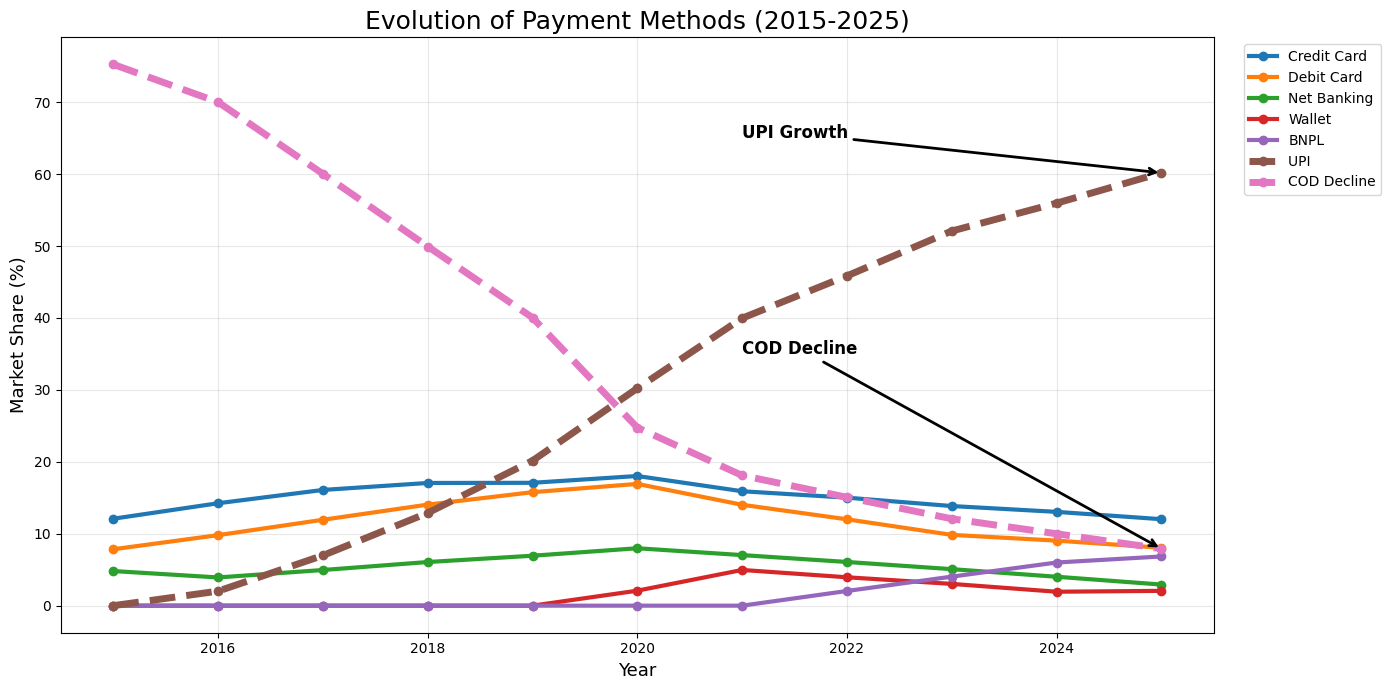

In [ ]:
#Q4: Payment Method Evolution (2015–2025)
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

# 2. PAYMENT TREND

payment_trend = df.groupby(['year','payment_method']).size().unstack(fill_value=0)

# 3. CONVERT TO MARKET SHARE %

payment_percent = payment_trend.div(payment_trend.sum(axis=1), axis=0) * 100

# 4. REORDER COLUMNS (IMPORTANT)

payment_percent = payment_percent[
    ['COD','Credit Card','Debit Card','Net Banking','Wallet','UPI','BNPL']
]
plt.style.use('default')
plt.figure(figsize=(14,7))


for col in payment_percent.columns:

    if col not in ['UPI', 'COD']:

        plt.plot(
            payment_percent.index,
            payment_percent[col],
            marker='o',
            linewidth=3,
            label=col
        )

# Highlight UPI
plt.plot(
    payment_percent.index,
    payment_percent['UPI'],
    linewidth=5,
    marker='o',
    linestyle='--',
    label='UPI '
)

# Highlight COD
plt.plot(
    payment_percent.index,
    payment_percent['COD'],
    linewidth=5,
    marker='o',
    linestyle='--',
    label='COD Decline'
)

plt.title(
    'Evolution of Payment Methods (2015-2025)',
    fontsize=18
)

plt.xlabel('Year', fontsize=13)
plt.ylabel('Market Share (%)', fontsize=13)

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

# UPI Growth Arrow
plt.annotate(
    'UPI Growth',
    xy=(2025, payment_percent.loc[2025, 'UPI']),
    xytext=(2021, 65),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    ),
    fontsize=12,
    fontweight='bold'
)

# COD Decline Arrow
plt.annotate(
    'COD Decline',
    xy=(2025, payment_percent.loc[2025, 'COD']),
    xytext=(2021, 35),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    ),
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

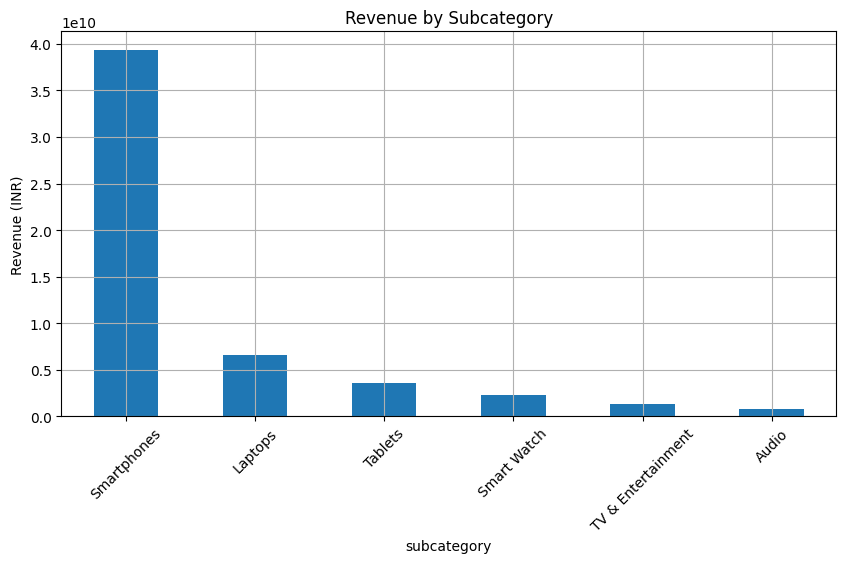

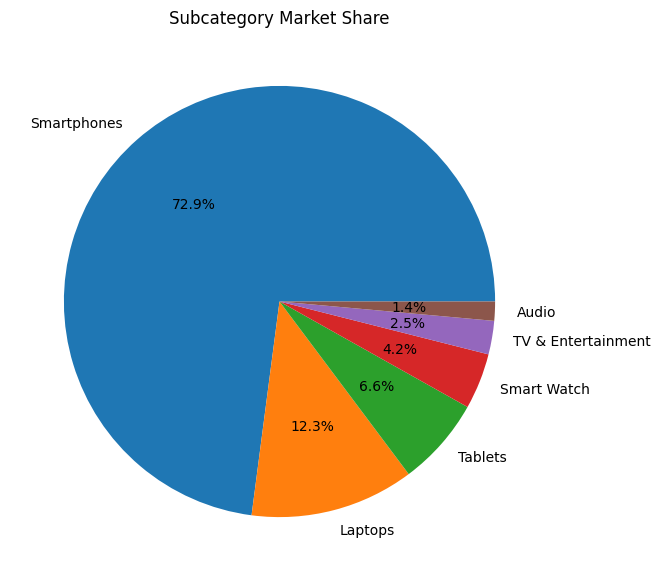

<Figure size 1000x600 with 0 Axes>

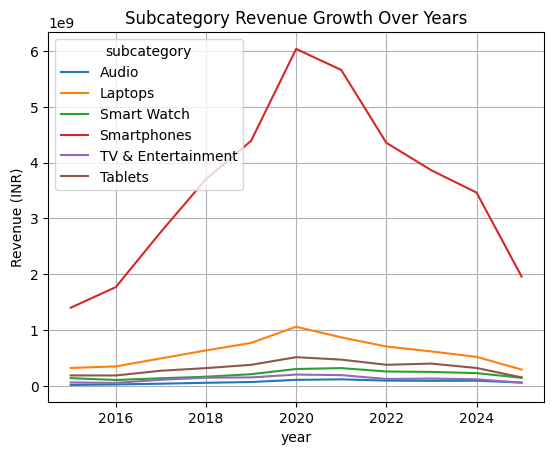

In [ ]:
#Q5: Subcategory Performance & Market Share
import squarify
# 1. PREPARE DATA

df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

# 2. REVENUE BY SUBCATEGORY

subcategory_revenue = df.groupby('subcategory')['final_amount_inr'].sum().sort_values(ascending=False)

# 3. MARKET SHARE (%)

subcategory_percent = subcategory_revenue / subcategory_revenue.sum() * 100

# 4. GROWTH OVER YEARS

subcategory_year = df.groupby(['year','subcategory'])['final_amount_inr'].sum().unstack()

# 5. BAR CHART

plt.figure(figsize=(10,5))
subcategory_revenue.plot(kind='bar')
plt.title("Revenue by Subcategory")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6. PIE CHART
plt.figure(figsize=(7,7))
plt.pie(subcategory_percent, labels=subcategory_percent.index, autopct='%1.1f%%')
plt.title("Subcategory Market Share")
plt.show()


# 7. GROWTH TREND

plt.figure(figsize=(10,6))
subcategory_year.plot()
plt.title("Subcategory Revenue Growth Over Years")
plt.ylabel("Revenue (INR)")
plt.grid()
plt.show()

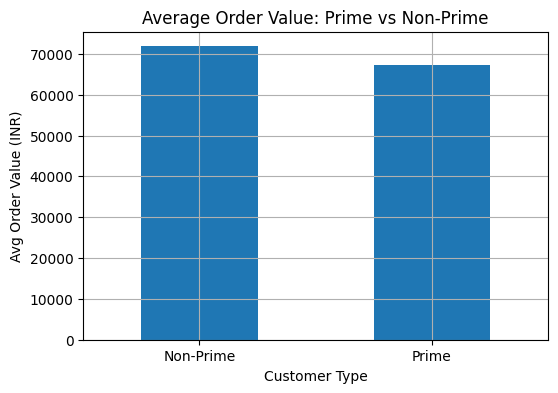

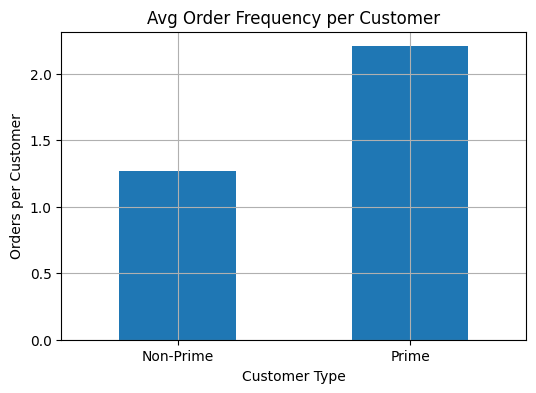

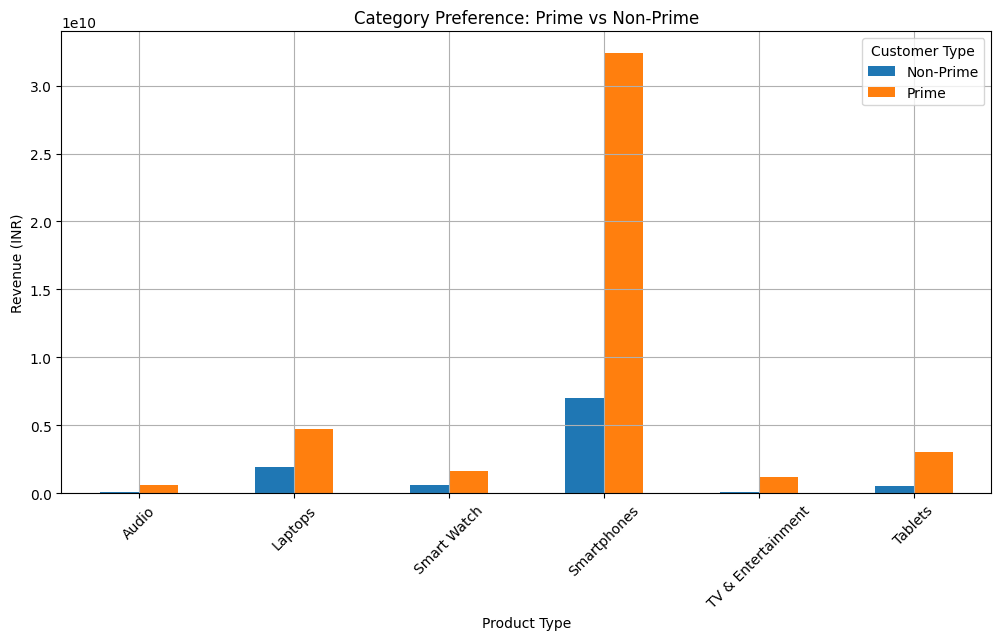

In [ ]:
#Q6: Prime vs Non-Prime Customer Analysis
# 1. PREPARE DATA

df['order_date'] = pd.to_datetime(df['order_date'])

# 2. AVERAGE ORDER VALUE (AOV)

aov = df.groupby('is_prime_eligible')['final_amount_inr'].mean()

plt.figure(figsize=(6,4))
aov.plot(kind='bar')
plt.title("Average Order Value: Prime vs Non-Prime")
plt.xlabel("Customer Type")
plt.ylabel("Avg Order Value (INR)")
plt.xticks([0,1], ['Non-Prime','Prime'], rotation=0)
plt.grid()
plt.show()

# 3. ORDER FREQUENCY

freq = df.groupby(['is_prime_eligible','customer_id']).size().groupby(level=0).mean()

plt.figure(figsize=(6,4))
freq.plot(kind='bar')
plt.title("Avg Order Frequency per Customer")
plt.xlabel("Customer Type")
plt.ylabel("Orders per Customer")
plt.xticks([0,1], ['Non-Prime','Prime'], rotation=0)
plt.grid()
plt.show()

# 4. CATEGORY PREFERENCE

category_pref = df.groupby(['is_prime_eligible','subcategory'])['final_amount_inr'].sum().unstack()

category_pref.T.plot(kind='bar', figsize=(12,6))
plt.legend(
    title='Customer Type',
    labels=['Non-Prime', 'Prime']
)

plt.title("Category Preference: Prime vs Non-Prime")
plt.ylabel("Revenue (INR)")
plt.xlabel("Product Type")
plt.xticks(rotation=45)
plt.grid()
plt.show()

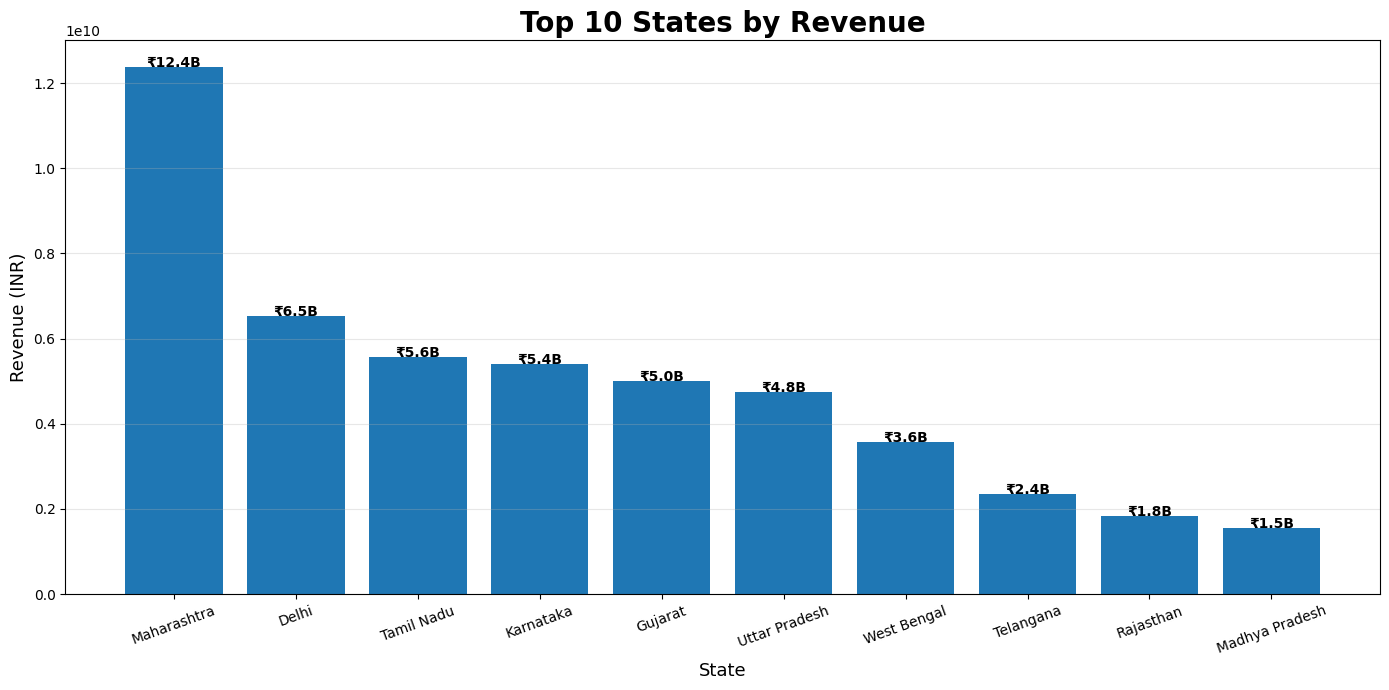

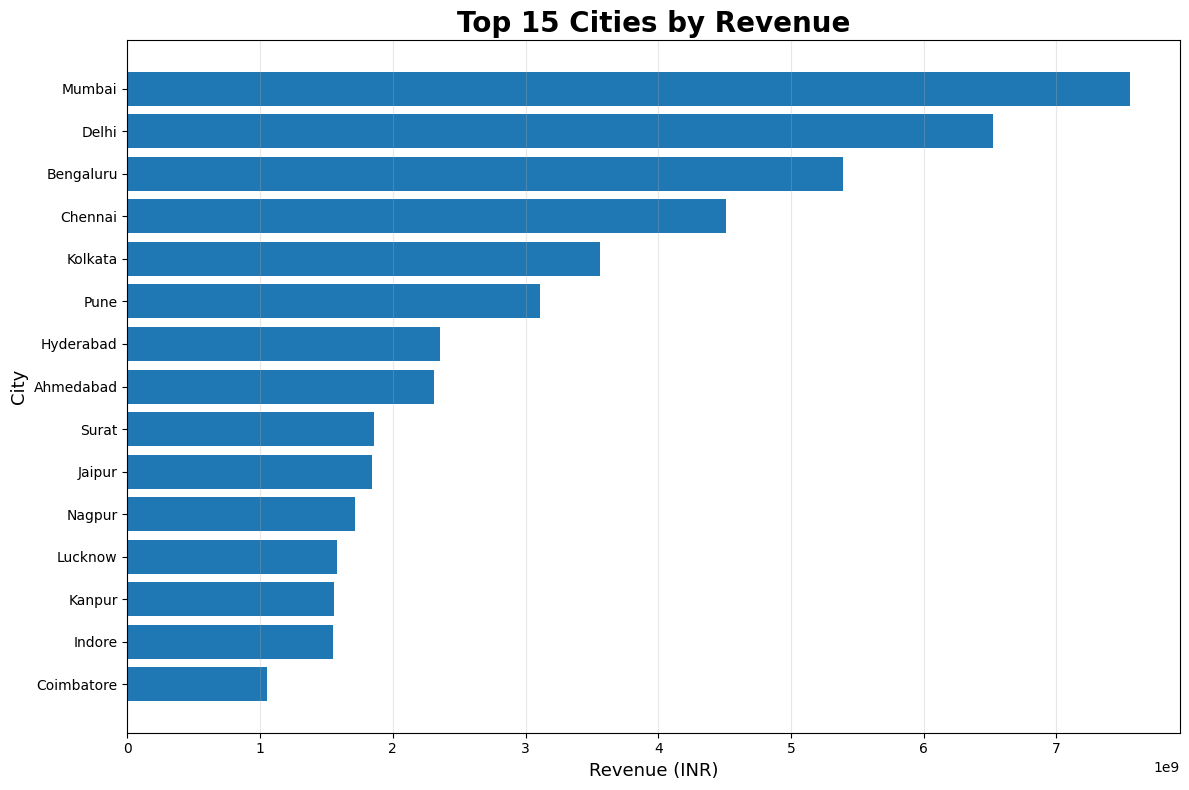

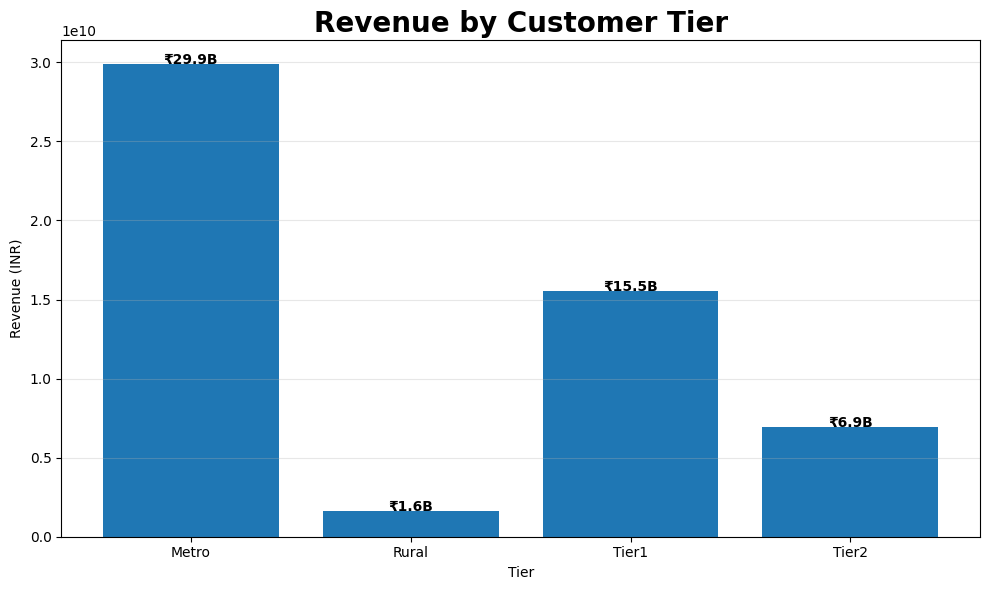

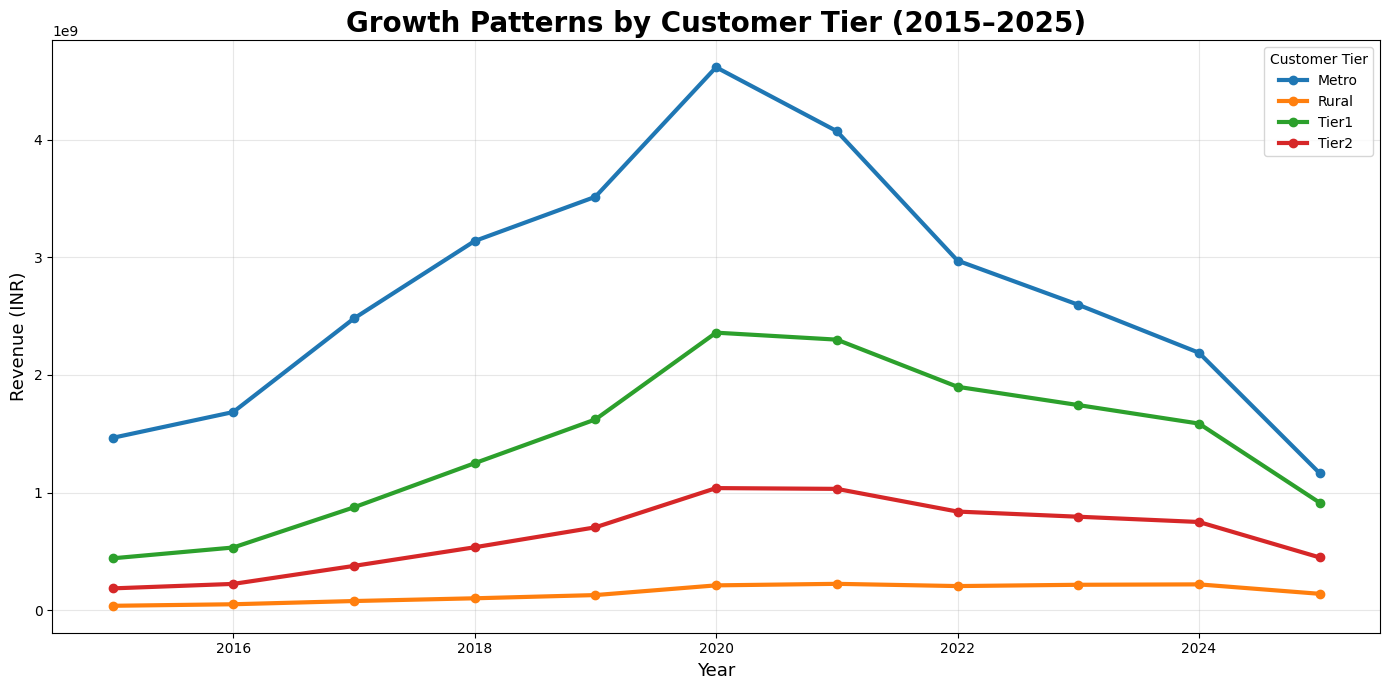

In [ ]:
#Q7: Geographic Revenue Distribution (State & City Analysis)

# STATE-WISE REVENUE

state_sales = (
    df.groupby('customer_state')['final_amount_inr']
    .sum()
    .reset_index()
)

state_sales.columns = ['State', 'Revenue']

# STATE CODE MAPPING

state_code_map = {
    'Andhra Pradesh': 'AP',
    'Bihar': 'BR',
    'Delhi': 'DL',
    'Gujarat': 'GJ',
    'Karnataka': 'KA',
    'Kerala': 'KL',
    'Madhya Pradesh': 'MP',
    'Maharashtra': 'MH',
    'Odisha': 'OR',
    'Punjab': 'PB',
    'Rajasthan': 'RJ',
    'Tamil Nadu': 'TN',
    'Telangana': 'TS',
    'Uttar Pradesh': 'UP',
    'West Bengal': 'WB'
}

# Add codes
state_sales['Code'] = (
    state_sales['State']
    .map(state_code_map)
)

# Remove missing mappings
state_sales = state_sales.dropna()

# INDIA MAP

fig = px.choropleth(

    state_sales,

    locations='Code',

    color='Revenue',

    hover_name='State',

    color_continuous_scale='Viridis',

    scope='asia',

    title='India State-wise Revenue Density'
)

# ZOOM INTO INDIA

fig.update_geos(
    visible=False,
    resolution=50,
    showcountries=True,
    countrycolor='Black',
    lataxis_range=[6, 38],
    lonaxis_range=[68, 98]
)

fig.update_layout(
    width=1000,
    height=700,
    title_x=0.5
)

fig.show()

# 3. TOP STATES BAR CHART

top_states = (
    state_sales
    .sort_values(by='Revenue', ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

bars = plt.bar(
    top_states['State'],
    top_states['Revenue']
)

# Revenue labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height/1e9:.1f}B",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top 10 States by Revenue',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('State', fontsize=13)
plt.ylabel('Revenue (INR)', fontsize=13)

plt.xticks(rotation=20)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. CITY-WISE REVENUE ANALYSIS

city_sales = (
    df.groupby('customer_city')['final_amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

city_sales.columns = ['City', 'Revenue']

# 5. TOP CITIES HORIZONTAL BAR CHART

plt.figure(figsize=(12,8))

plt.barh(
    city_sales['City'],
    city_sales['Revenue']
)

plt.gca().invert_yaxis()

plt.title(
    'Top 15 Cities by Revenue',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Revenue (INR)', fontsize=13)
plt.ylabel('City', fontsize=13)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. TIER-WISE REVENUE ANALYSIS

tier_sales = (
    df.groupby('customer_tier')['final_amount_inr']
    .sum()
    .reset_index()
)

tier_sales.columns = ['Tier', 'Revenue']

# 7. TIER REVENUE BAR CHART

plt.figure(figsize=(10,6))

bars = plt.bar(
    tier_sales['Tier'],
    tier_sales['Revenue']
)

# Labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height/1e9:.1f}B",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Revenue by Customer Tier',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Tier')
plt.ylabel('Revenue (INR)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 8. TIER GROWTH PATTERN

tier_growth = (
    df.groupby(['order_year', 'customer_tier'])['final_amount_inr']
    .sum()
    .unstack(fill_value=0)
)

# 9. TIER GROWTH LINE CHART

plt.figure(figsize=(14,7))

for col in tier_growth.columns:

    plt.plot(
        tier_growth.index,
        tier_growth[col],
        marker='o',
        linewidth=3,
        label=col
    )

plt.title(
    'Growth Patterns by Customer Tier (2015–2025)',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=13)
plt.ylabel('Revenue (INR)', fontsize=13)

plt.legend(title='Customer Tier')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

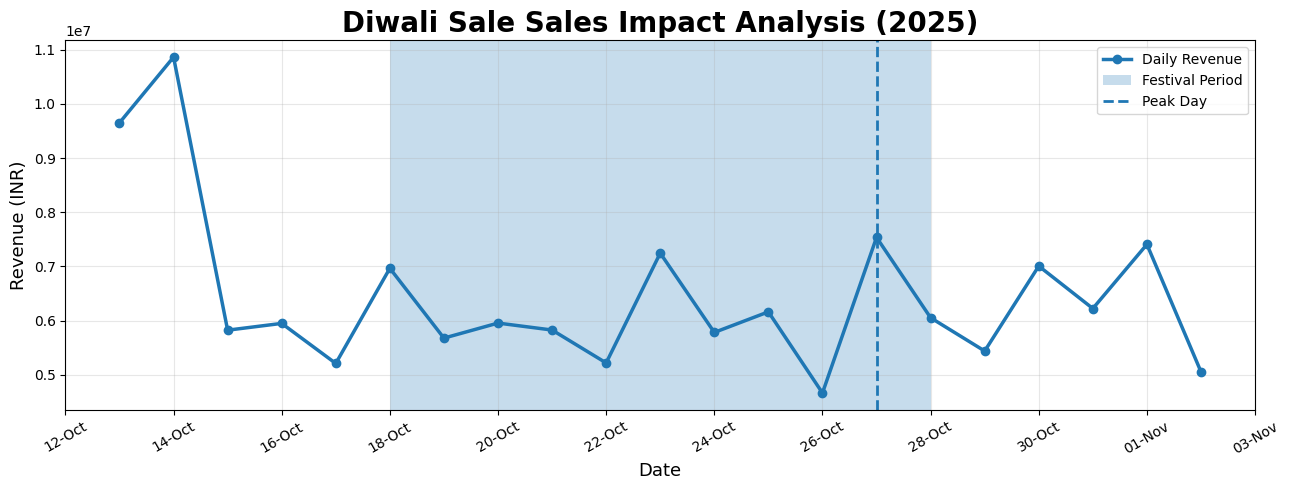

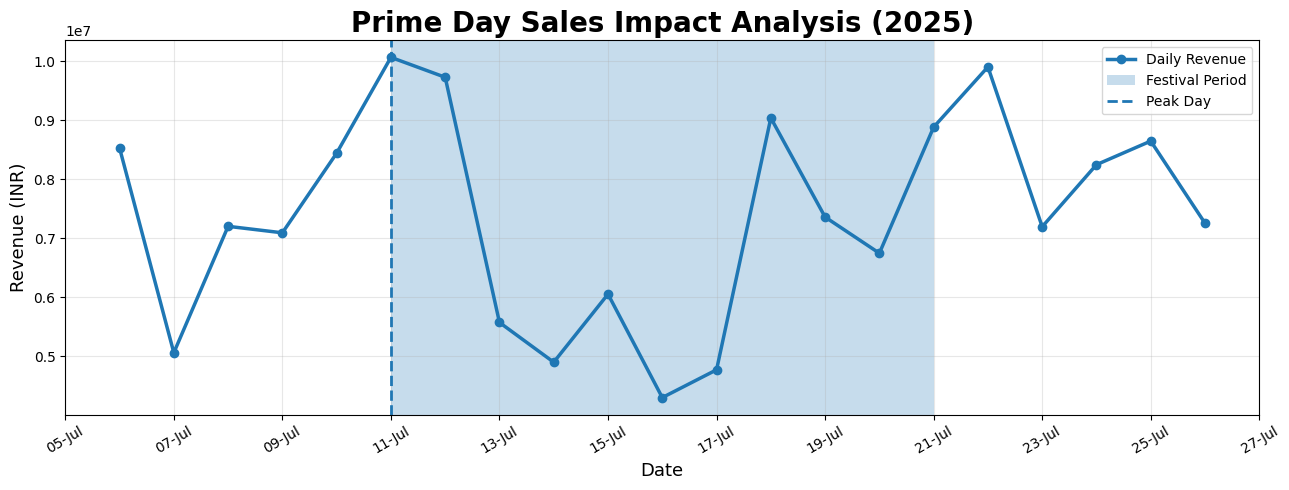

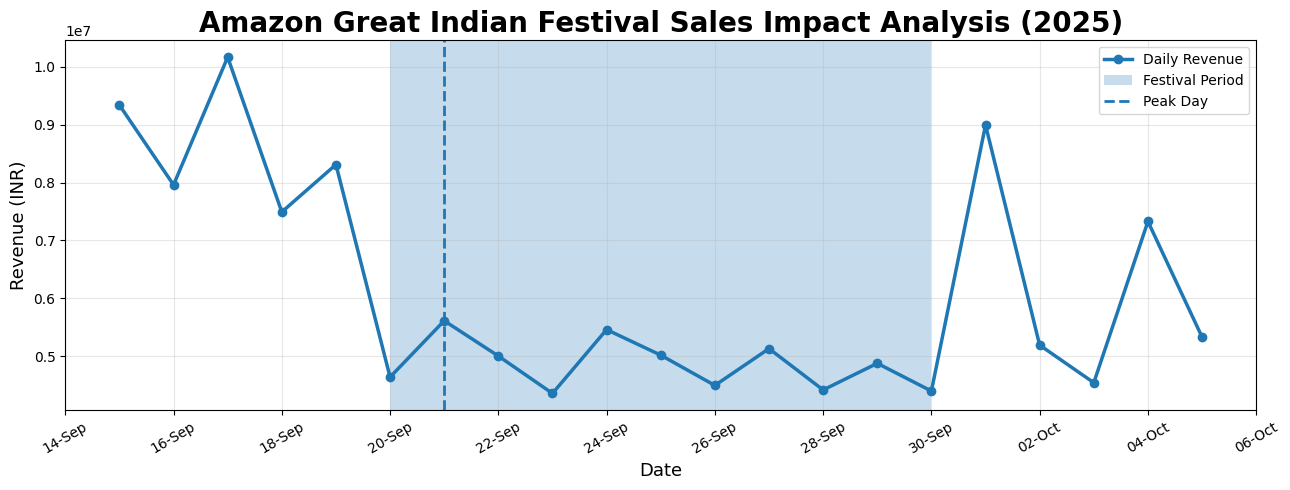

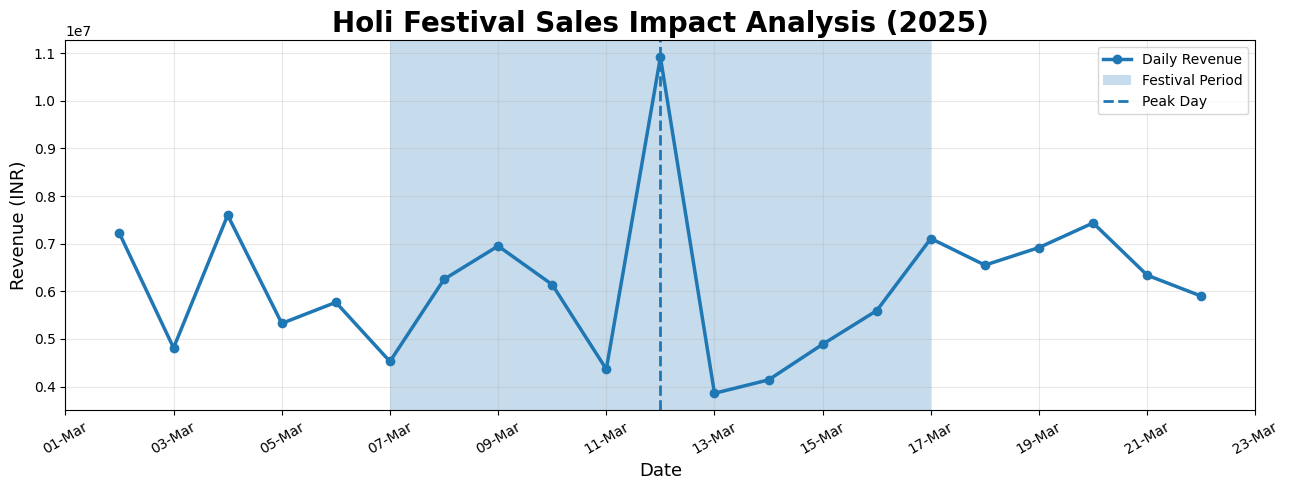

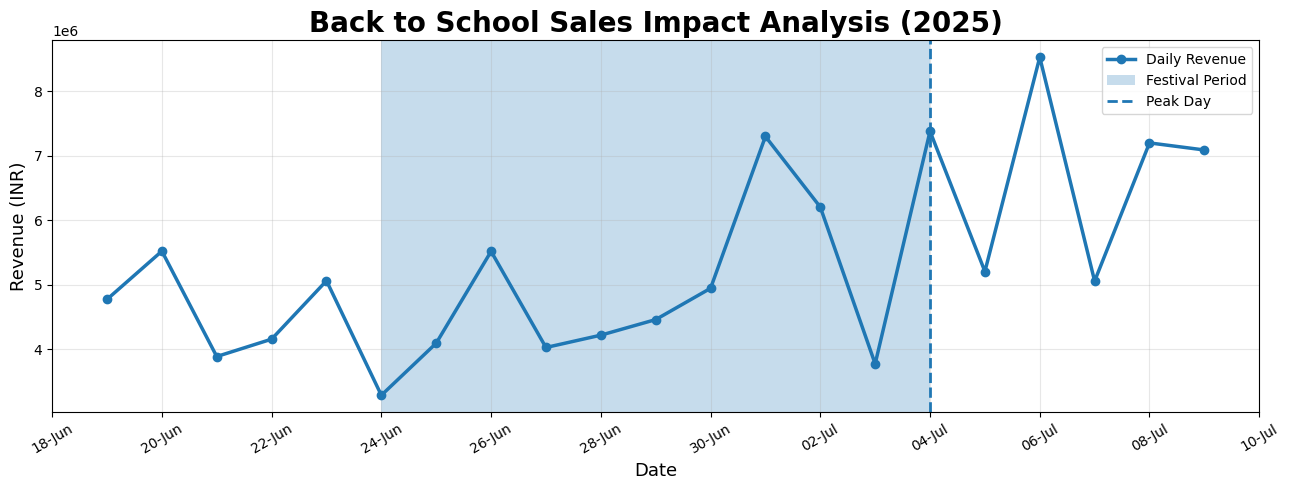

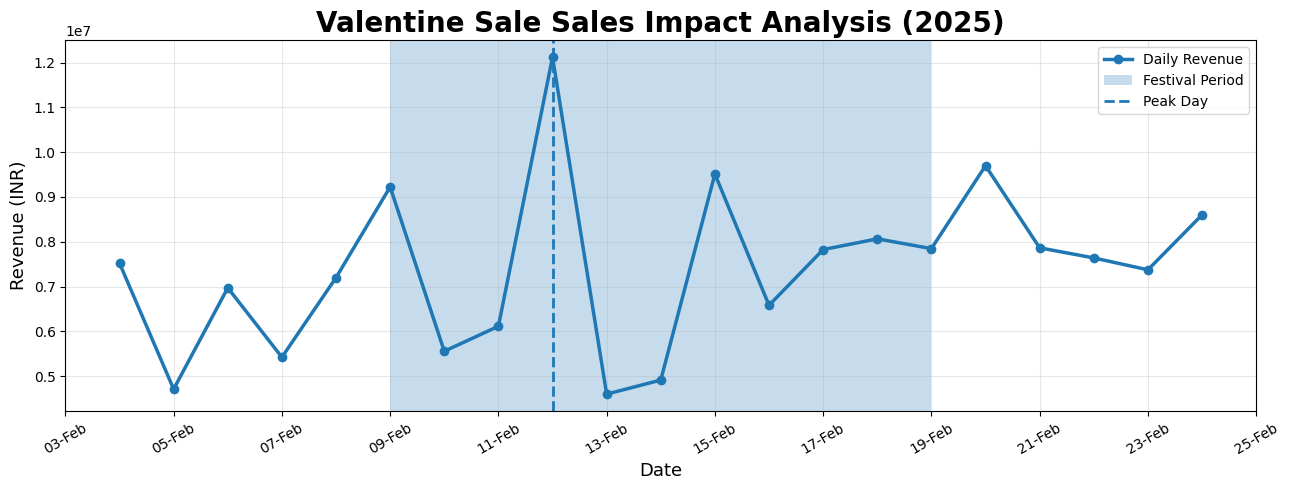

In [ ]:
#Q8: Festival Impact Analysis (2025)
import matplotlib.dates as mdates

# 1. PREP DATA

df['order_date'] = pd.to_datetime(df['order_date'])

# Filter only 2025 data
df_year = df[
    df['order_date'].dt.year == 2025
].copy()

# 2. TOTAL DAILY SALES

daily_sales = (
    df_year.groupby('order_date')['final_amount_inr']
    .sum()
    .reset_index()
)

# 3. IMPORTANT FESTIVALS

festivals = [
    'Diwali Sale',
    'Prime Day',
    'Amazon Great Indian Festival',
    'Holi Festival',
    'Back to School',
    'Valentine Sale'
]

# 4. LOOP THROUGH FESTIVALS

for fest in festivals:

    # Festival-specific transactions
    fest_df = df_year[
        df_year['festival_name'] == fest
    ]

    # Skip empty festivals
    if fest_df.empty:
        continue

    # FESTIVAL DATES

    festival_dates = sorted(
        fest_df['order_date'].unique()
    )

    # Center festival day
    center_day = festival_dates[
        len(festival_dates)//2
    ]

    # FESTIVAL WINDOW

    start = center_day - pd.Timedelta(days=5)
    end   = center_day + pd.Timedelta(days=5)

    # BEFORE / AFTER WINDOW

    before_start = start - pd.Timedelta(days=5)
    after_end = end + pd.Timedelta(days=5)

    # TOTAL REVENUE AROUND FESTIVAL

    plot_df = daily_sales[
        (daily_sales['order_date'] >= before_start) &
        (daily_sales['order_date'] <= after_end)
    ]

    # PEAK DAY INSIDE FESTIVAL WINDOW

    festival_window_df = plot_df[
        (plot_df['order_date'] >= start) &
        (plot_df['order_date'] <= end)
    ]

    peak_day = festival_window_df.loc[
        festival_window_df['final_amount_inr'].idxmax(),
        'order_date'
    ]

    # PLOT

    plt.figure(figsize=(13,5))

    plt.plot(
        plot_df['order_date'],
        plot_df['final_amount_inr'],
        marker='o',
        linewidth=2.5,
        label='Daily Revenue'
    )

    # Festival shaded region
    plt.axvspan(
        start,
        end,
        alpha=0.25,
        label='Festival Period'
    )

    # Peak day line
    plt.axvline(
        peak_day,
        linestyle='--',
        linewidth=2,
        label='Peak Day'
    )

    # DATE FORMATTING

    ax = plt.gca()

    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=2)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d-%b')
    )

    plt.xticks(rotation=30)

    # TITLES & LABELS

    plt.title(
        f"{fest} Sales Impact Analysis (2025)",
        fontsize=20,
        fontweight='bold'
    )

    plt.xlabel(
        "Date",
        fontsize=13
    )

    plt.ylabel(
        "Revenue (INR)",
        fontsize=13
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20412\2077558493.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_2025['customer_age_group'] = pd.Categorical(


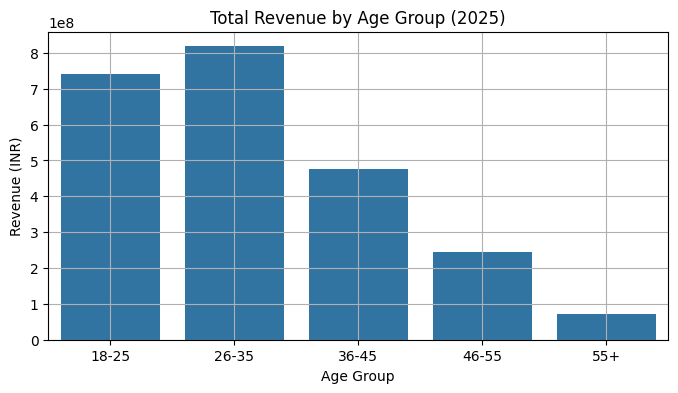

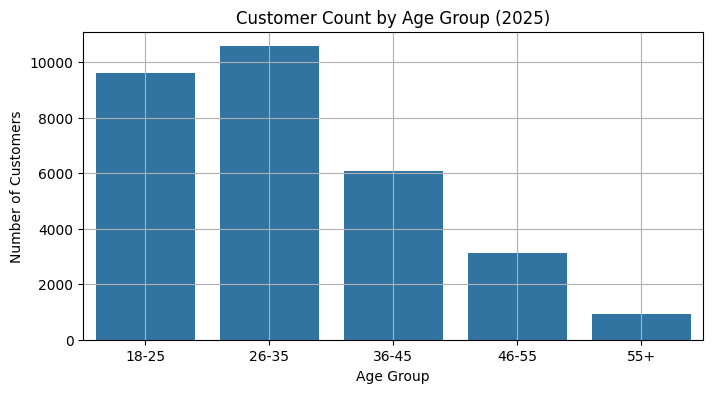

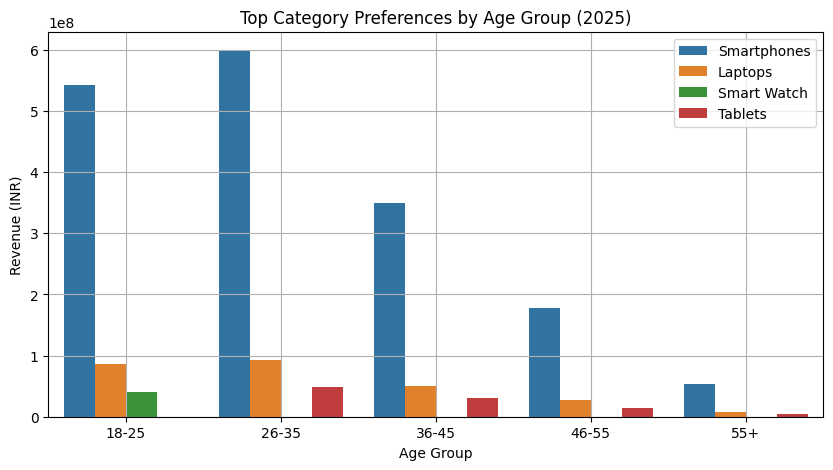

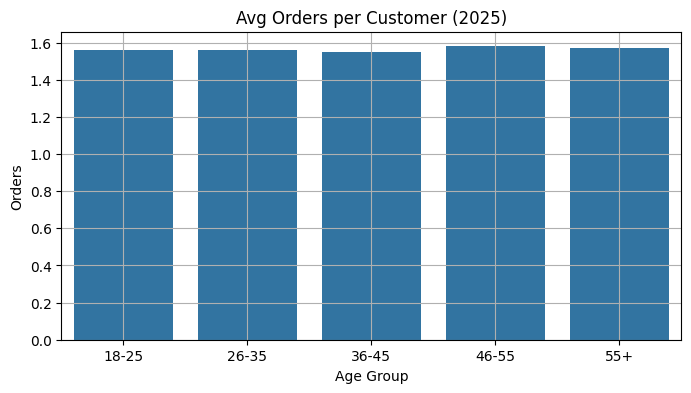

In [ ]:
#Q9: Age Group Analysis (2025)

df['order_date'] = pd.to_datetime(df['order_date'])

df_2025 = df[df['order_date'].dt.year == 2025].copy()

# Ensure correct order
age_order = ['18-25','26-35','36-45','46-55','55+']
df_2025['customer_age_group'] = pd.Categorical(
    df_2025['customer_age_group'],
    categories=age_order,
    ordered=True
)

# 2. TOTAL REVENUE (BEST METRIC)

revenue = df_2025.groupby('customer_age_group')['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=revenue, x='customer_age_group', y='final_amount_inr')
plt.title("Total Revenue by Age Group (2025)")
plt.ylabel("Revenue (INR)")
plt.xlabel("Age Group")
plt.grid()
plt.show()

# 3. CUSTOMER COUNT

customers = df_2025.groupby('customer_age_group')['customer_id'].nunique().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=customers, x='customer_age_group', y='customer_id')
plt.title("Customer Count by Age Group (2025)")
plt.ylabel("Number of Customers")
plt.xlabel("Age Group")
plt.grid()
plt.show()

# 4. CATEGORY PREFERENCE

category_pref = df_2025.groupby(['customer_age_group','subcategory'])['final_amount_inr'].sum().reset_index()

top_categories = category_pref.sort_values(['customer_age_group','final_amount_inr'], ascending=[True,False])\
                             .groupby('customer_age_group').head(3)

plt.figure(figsize=(10,5))
sns.barplot(data=top_categories, x='customer_age_group', y='final_amount_inr', hue='subcategory')
plt.title("Top Category Preferences by Age Group (2025)")
plt.ylabel("Revenue (INR)")
plt.xlabel("Age Group")
plt.legend(bbox_to_anchor=(1,1))
plt.grid()
plt.show()

# 5. SHOPPING FREQUENCY (CORRECT WAY)

orders = df_2025.groupby(['customer_id','customer_age_group']).size().reset_index(name='orders')

freq = orders.groupby('customer_age_group')['orders'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=freq, x='customer_age_group', y='orders')
plt.title("Avg Orders per Customer (2025)")
plt.ylabel("Orders")
plt.xlabel("Age Group")
plt.grid()
plt.show()

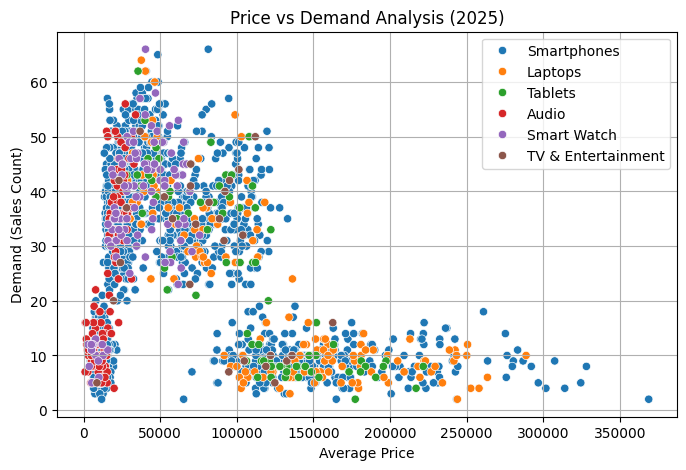

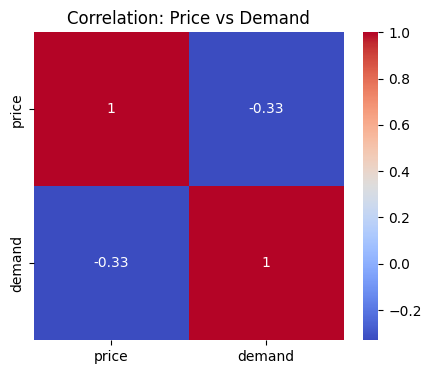

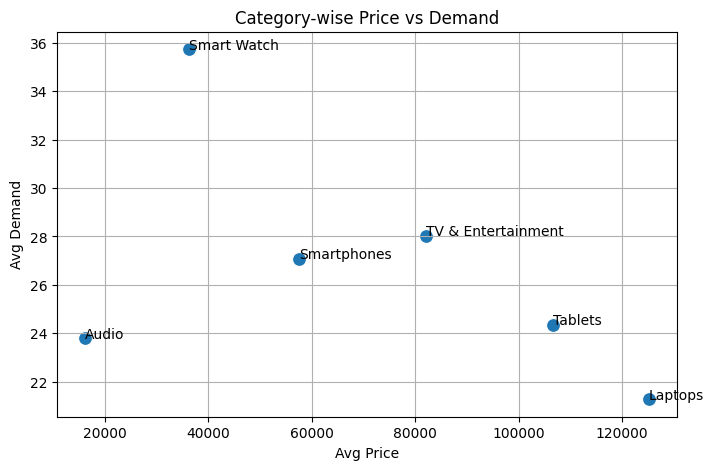

In [ ]:
#Q10: Price vs Demand Analysis (2025)

# Demand = number of times product sold
# Only 2025 data


# Demand analysis
demand = df_2025.groupby(
    ['product_id','subcategory']
).agg({
    'final_amount_inr':'mean',
    'transaction_id':'nunique'
}).reset_index()

demand.rename(columns={
    'final_amount_inr':'price',
    'transaction_id':'demand'
}, inplace=True)

# 2. SCATTER PLOT (PRICE VS DEMAND)

plt.figure(figsize=(8,5))
sns.scatterplot(data=demand, x='price', y='demand', hue='subcategory')
plt.title("Price vs Demand Analysis (2025)")
plt.xlabel("Average Price")
plt.ylabel("Demand (Sales Count)")
plt.legend(bbox_to_anchor=(1,1))
plt.grid()
plt.show()

# 3. CORRELATION MATRIX

corr = demand[['price','demand']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Price vs Demand")
plt.show()


# 4. CATEGORY LEVEL ANALYSIS

category_analysis = demand.groupby('subcategory').agg({
    'price':'mean',
    'demand':'mean'
}).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(data=category_analysis, x='price', y='demand', s=100)
for i in range(len(category_analysis)):
    plt.text(category_analysis['price'][i],
             category_analysis['demand'][i],
             category_analysis['subcategory'][i])

plt.title("Category-wise Price vs Demand")
plt.xlabel("Avg Price")
plt.ylabel("Avg Demand")
plt.grid()
plt.show()

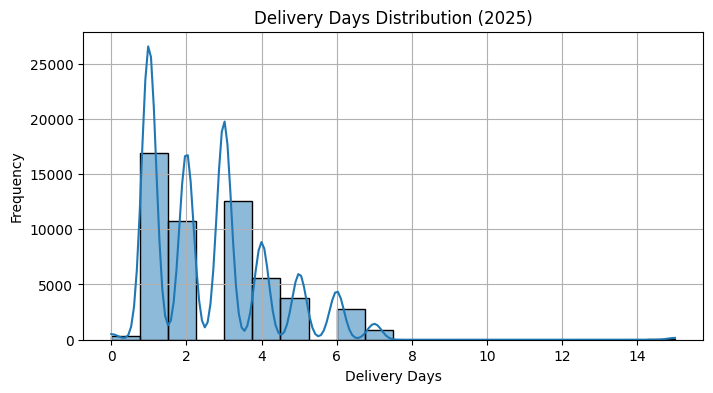

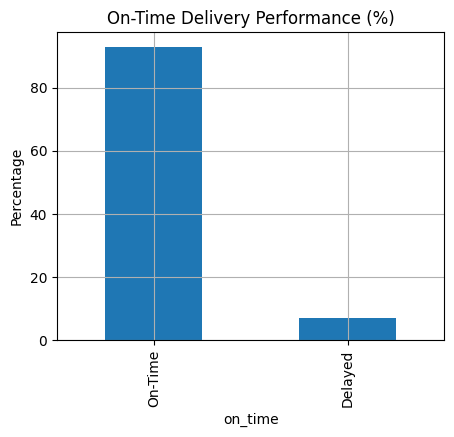

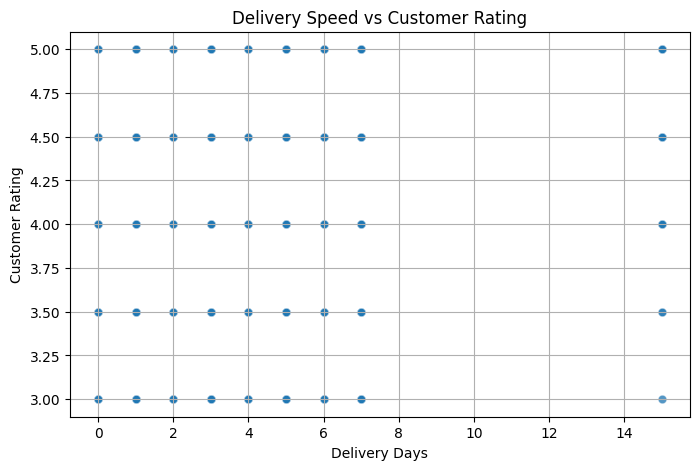

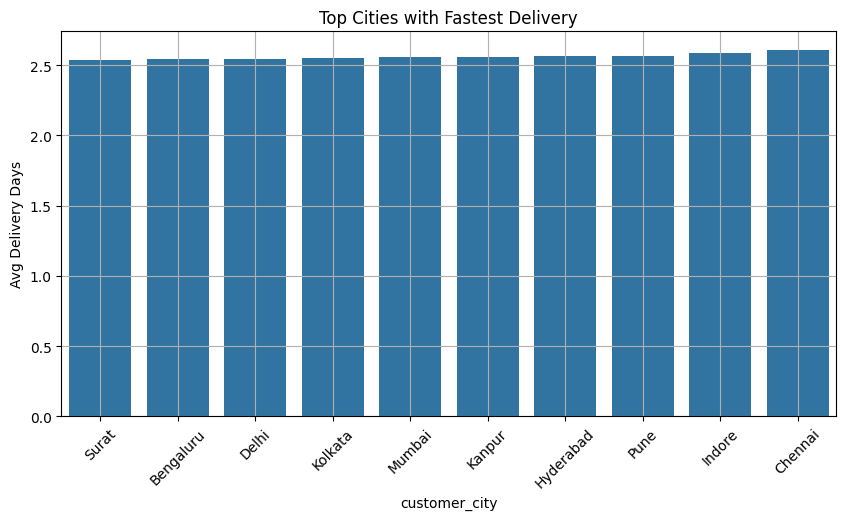

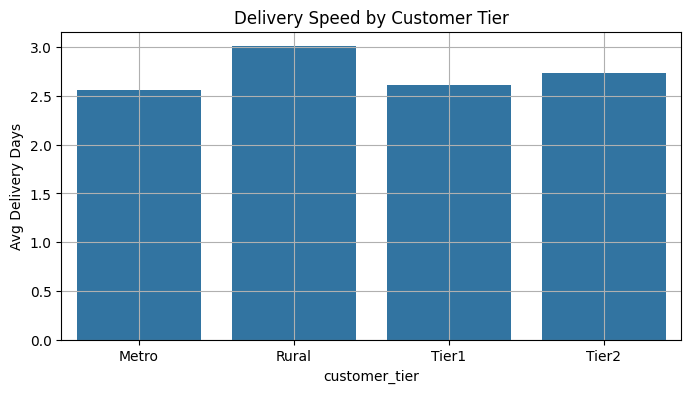

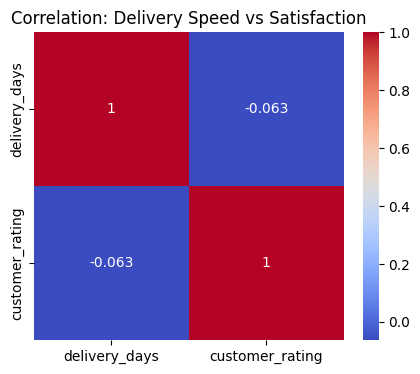

In [ ]:
#Q11: Delivery Speed & Customer Satisfaction (2025)



plt.figure(figsize=(8,4))
sns.histplot(df_2025['delivery_days'], bins=20, kde=True)
plt.title("Delivery Days Distribution (2025)")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# 2. ON-TIME PERFORMANCE

df_2025['on_time'] = df_2025['delivery_days'].apply(lambda x: 'On-Time' if x <= 5 else 'Delayed')

on_time_rate = df_2025['on_time'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,4))
on_time_rate.plot(kind='bar')
plt.title("On-Time Delivery Performance (%)")
plt.ylabel("Percentage")
plt.grid()
plt.show()

# 3. DELIVERY SPEED vs CUSTOMER SATISFACTION

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_2025, x='delivery_days', y='customer_rating', alpha=0.3)
plt.title("Delivery Speed vs Customer Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")
plt.grid()
plt.show()

# 4. CITY LEVEL PERFORMANCE (TOP 10)

city_perf = df_2025.groupby('customer_city').agg({
    'delivery_days':'mean',
    'customer_rating':'mean'
}).sort_values('delivery_days').head(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=city_perf, x='customer_city', y='delivery_days')
plt.title("Top Cities with Fastest Delivery")
plt.xticks(rotation=45)
plt.ylabel("Avg Delivery Days")
plt.grid()
plt.show()

# 5. CUSTOMER TIER ANALYSIS

tier_perf = df_2025.groupby('customer_tier').agg({
    'delivery_days':'mean',
    'customer_rating':'mean'
}).reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=tier_perf, x='customer_tier', y='delivery_days')
plt.title("Delivery Speed by Customer Tier")
plt.ylabel("Avg Delivery Days")
plt.grid()
plt.show()

# 6. CORRELATION (KEY INSIGHT)

corr = df_2025[['delivery_days','customer_rating']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Delivery Speed vs Satisfaction")
plt.show()

Overall Return Rate: 9.68%


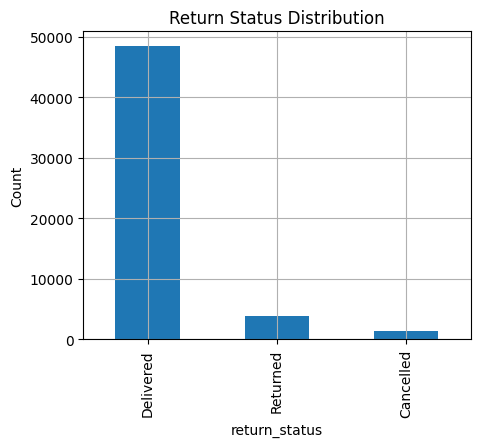

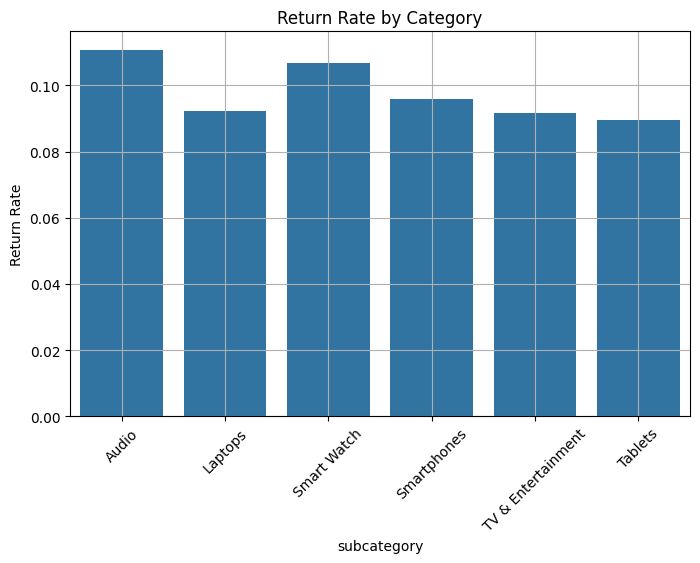

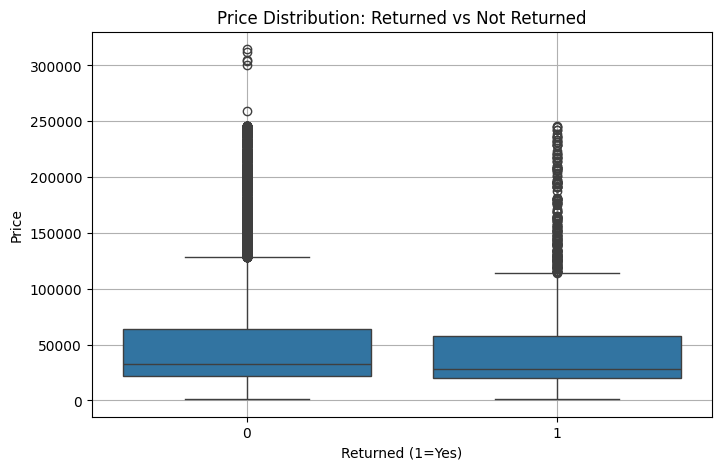

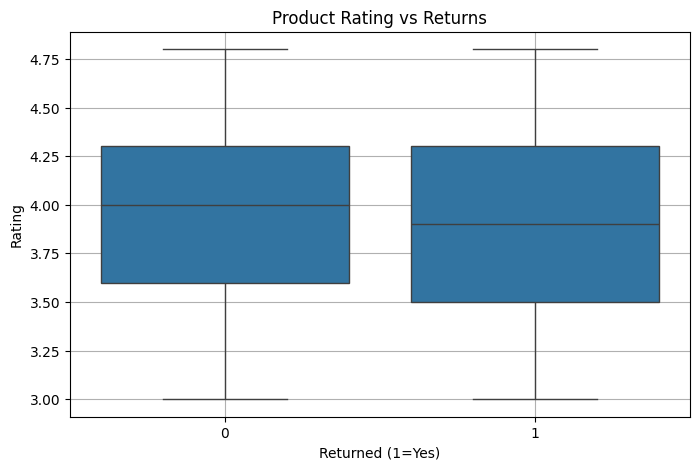

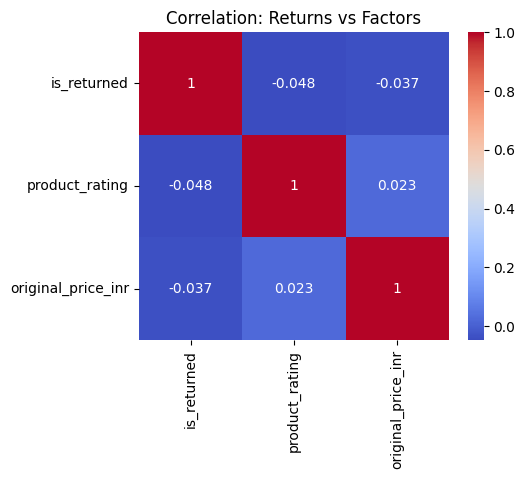

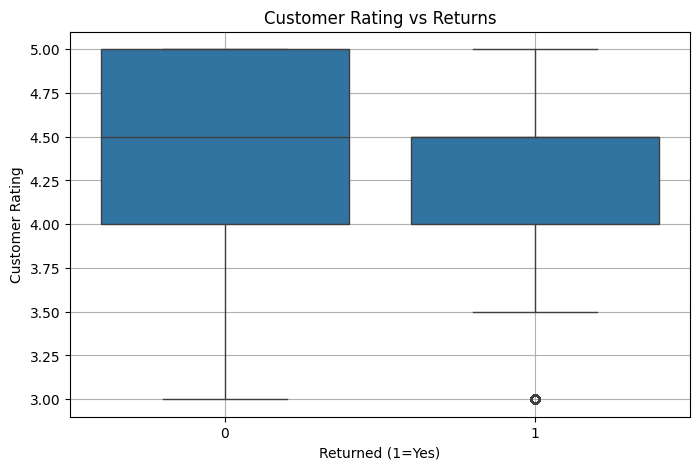

In [ ]:
#Q12: Return Analysis & Product Feedback (2025)

df_2025['is_returned'] = df_2025['return_status'].apply(lambda x: 1 if x != 'Delivered' else 0)

return_rate = df_2025['is_returned'].mean() * 100

print(f"Overall Return Rate: {return_rate:.2f}%")

# 2. RETURN DISTRIBUTION

plt.figure(figsize=(5,4))
df_2025['return_status'].value_counts().plot(kind='bar')
plt.title("Return Status Distribution")
plt.ylabel("Count")
plt.grid()
plt.show()

# 3. RETURNS BY CATEGORY

cat_returns = df_2025.groupby('subcategory')['is_returned'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=cat_returns, x='subcategory', y='is_returned')
plt.title("Return Rate by Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4. PRICE vs RETURNS

plt.figure(figsize=(8,5))
sns.boxplot(data=df_2025, x='is_returned', y='original_price_inr')
plt.title("Price Distribution: Returned vs Not Returned")
plt.xlabel("Returned (1=Yes)")
plt.ylabel("Price")
plt.grid()
plt.show()

# 5. PRODUCT RATING vs RETURNS

plt.figure(figsize=(8,5))
sns.boxplot(data=df_2025, x='is_returned', y='product_rating')
plt.title("Product Rating vs Returns")
plt.xlabel("Returned (1=Yes)")
plt.ylabel("Rating")
plt.grid()
plt.show()

# 6. CORRELATION MATRIX

corr = df_2025[['is_returned','product_rating','original_price_inr']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Returns vs Factors")
plt.show()

# 7. CUSTOMER SATISFACTION (RETURN vs RATING)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_2025, x='is_returned', y='customer_rating')
plt.title("Customer Rating vs Returns")
plt.xlabel("Returned (1=Yes)")
plt.ylabel("Customer Rating")
plt.grid()
plt.show()

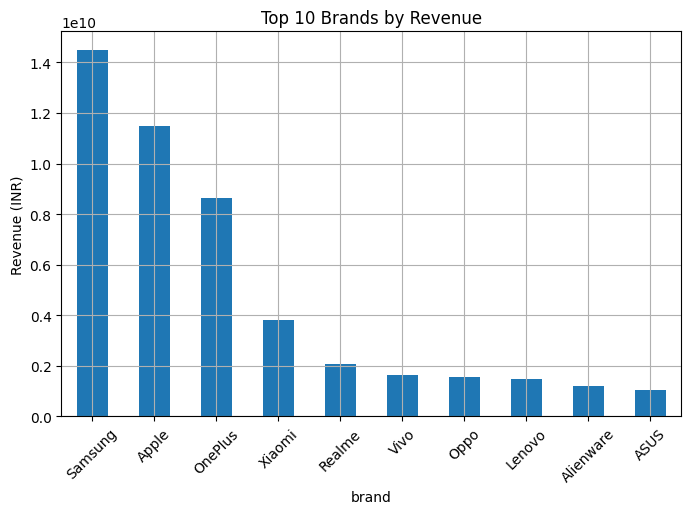

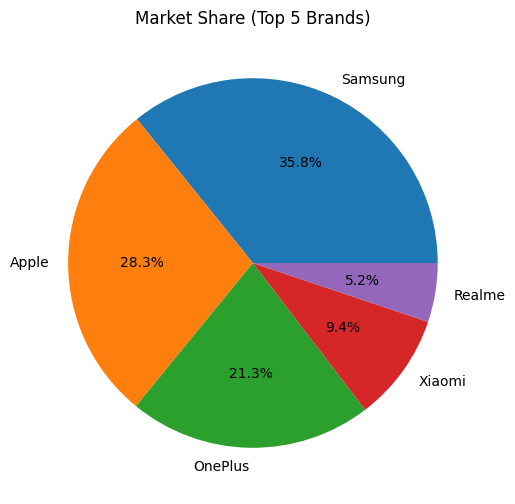

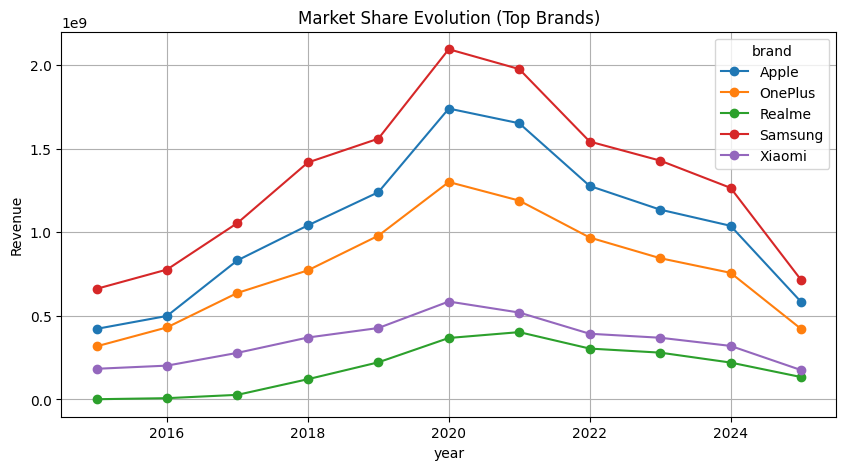

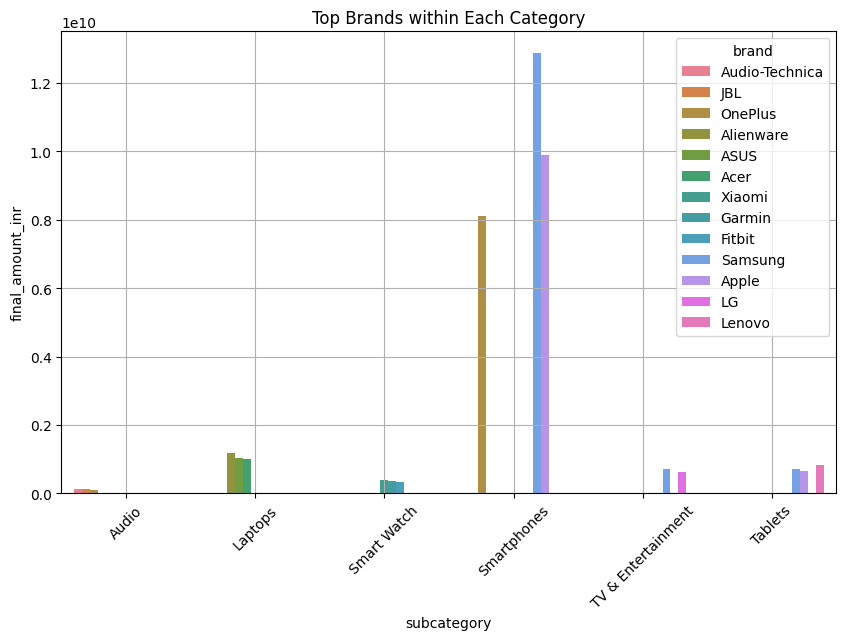

In [ ]:
#Q13: Brand Performance & Market Share Analysis (2025)

df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

# 2. BRAND PERFORMANCE (TOTAL REVENUE)

brand_perf = df.groupby('brand')['final_amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
brand_perf.plot(kind='bar')
plt.title("Top 10 Brands by Revenue")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 3. MARKET SHARE (OVERALL)

market_share = df.groupby('brand')['final_amount_inr'].sum()
market_share = market_share / market_share.sum()

top_brands = market_share.sort_values(ascending=False).head(5)

plt.figure(figsize=(6,6))
top_brands.plot(kind='pie', autopct='%1.1f%%')
plt.title("Market Share (Top 5 Brands)")
plt.ylabel("")
plt.show()

# 4. MARKET SHARE EVOLUTION (YEARLY)

brand_year = df.groupby(['year','brand'])['final_amount_inr'].sum().reset_index()

# Keep top brands only (to avoid clutter)
top5 = df.groupby('brand')['final_amount_inr'].sum().nlargest(5).index
brand_year = brand_year[brand_year['brand'].isin(top5)]

pivot = brand_year.pivot(index='year', columns='brand', values='final_amount_inr')

pivot.plot(figsize=(10,5), marker='o')
plt.title("Market Share Evolution (Top Brands)")
plt.ylabel("Revenue")
plt.grid()
plt.show()

# 5. CATEGORY-WISE BRAND COMPETITION

cat_brand = df.groupby(['subcategory','brand'])['final_amount_inr'].sum().reset_index()

# top brands per category
cat_top = cat_brand.sort_values(['subcategory','final_amount_inr'], ascending=[True,False]).groupby('subcategory').head(3)

plt.figure(figsize=(10,6))
sns.barplot(data=cat_top, x='subcategory', y='final_amount_inr', hue='brand')
plt.title("Top Brands within Each Category")
plt.xticks(rotation=45)
plt.grid()
plt.show()

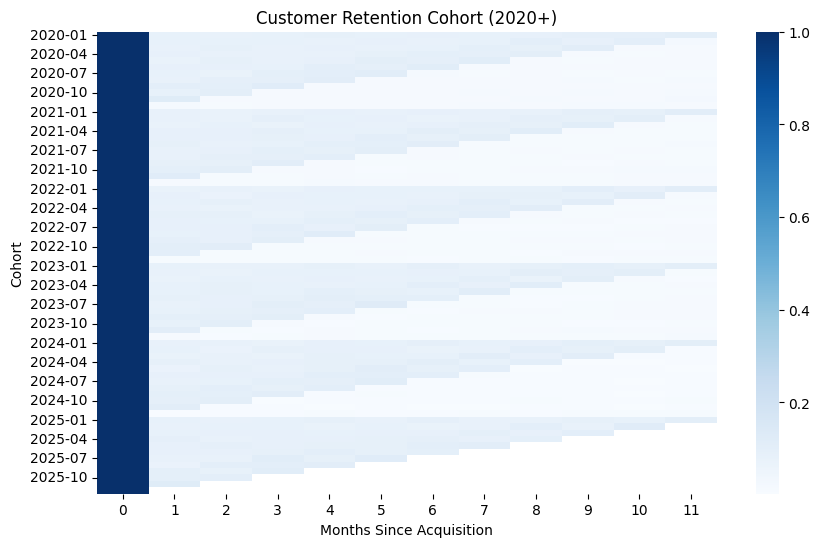

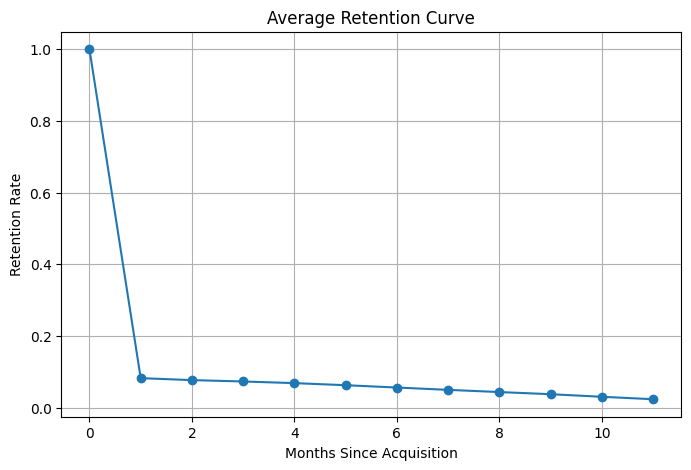

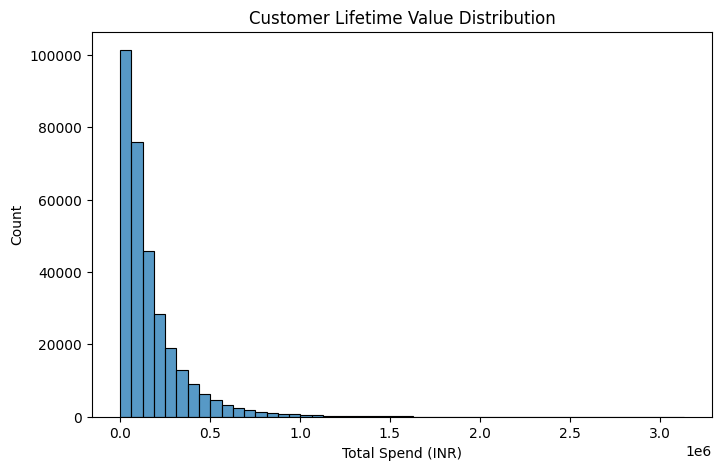

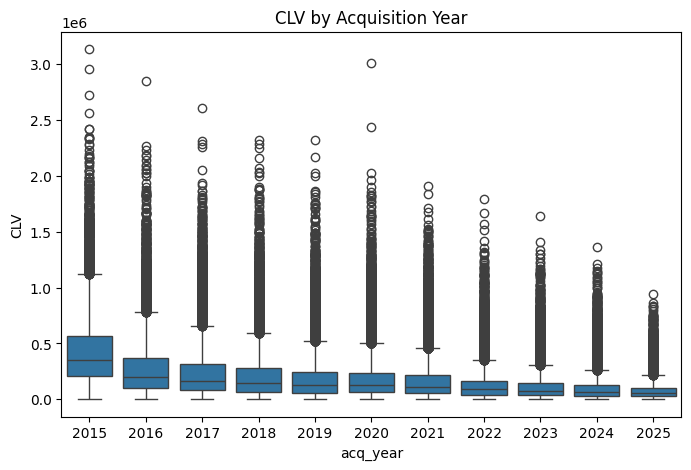

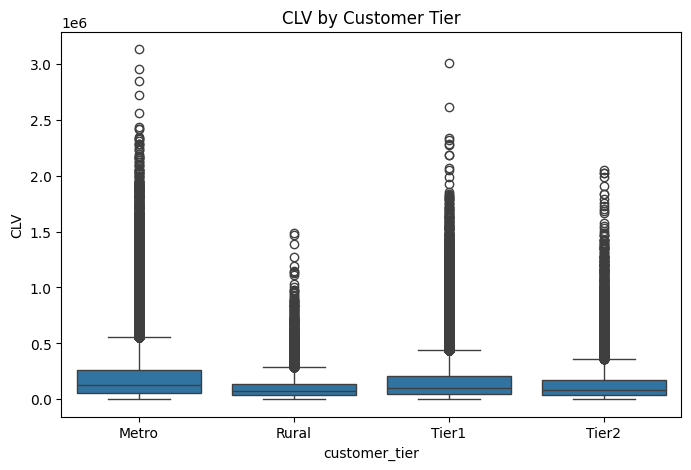

In [ ]:
#Q14: Customer Lifetime Value (CLV) & Retention Analysis

df['order_date'] = pd.to_datetime(df['order_date'])

df_clv = df[df['order_date'].dt.year >= 2020].copy()

# Cohort
df_clv['cohort'] = df_clv.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
df_clv['order_month'] = df_clv['order_date'].dt.to_period('M')

# 2. COHORT INDEX

df_clv['cohort_index'] = (df_clv['order_month'] - df_clv['cohort']).apply(lambda x: x.n)

# 3. RETENTION TABLE

cohort_data = df_clv.groupby(['cohort','cohort_index'])['customer_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_id')

# Retention %
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

# LIMIT TO FIRST 12 MONTHS
retention = retention.iloc[:, :12]

# 4. HEATMAP

plt.figure(figsize=(10,6))
sns.heatmap(retention, cmap='Blues')
plt.title("Customer Retention Cohort (2020+)")
plt.ylabel("Cohort")
plt.xlabel("Months Since Acquisition")
plt.show()

# 5. RETENTION CURVE (Mean)

avg_retention = retention.mean()

plt.figure(figsize=(8,5))
avg_retention.plot(marker='o')
plt.title("Average Retention Curve")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Retention Rate")
plt.grid()
plt.show()

# 6. CLV DISTRIBUTION

clv = df.groupby('customer_id')['final_amount_inr'].sum()

plt.figure(figsize=(8,5))
sns.histplot(clv, bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Total Spend (INR)")
plt.show()

# 7. CLV BY ACQUISITION YEAR

df['acq_year'] = df.groupby('customer_id')['order_date'].transform('min').dt.year

clv_year = df.groupby(['customer_id','acq_year'])['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.boxplot(data=clv_year, x='acq_year', y='final_amount_inr')
plt.title("CLV by Acquisition Year")
plt.ylabel("CLV")
plt.show()

# 8. CLV BY CUSTOMER TIER

if 'customer_tier' in df.columns:
    clv_tier = df.groupby(['customer_id','customer_tier'])['final_amount_inr'].sum().reset_index()

    plt.figure(figsize=(8,5))
    sns.boxplot(data=clv_tier, x='customer_tier', y='final_amount_inr')
    plt.title("CLV by Customer Tier")
    plt.ylabel("CLV")
    plt.show()

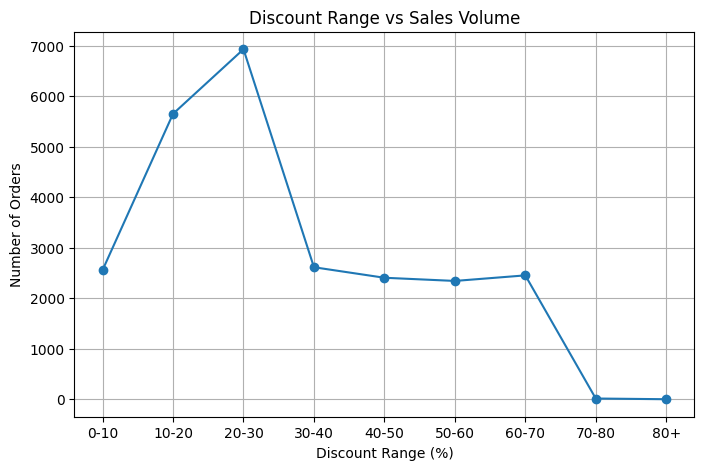

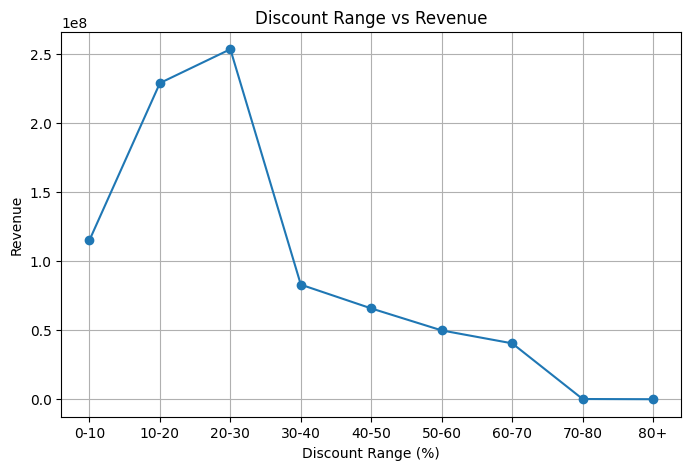

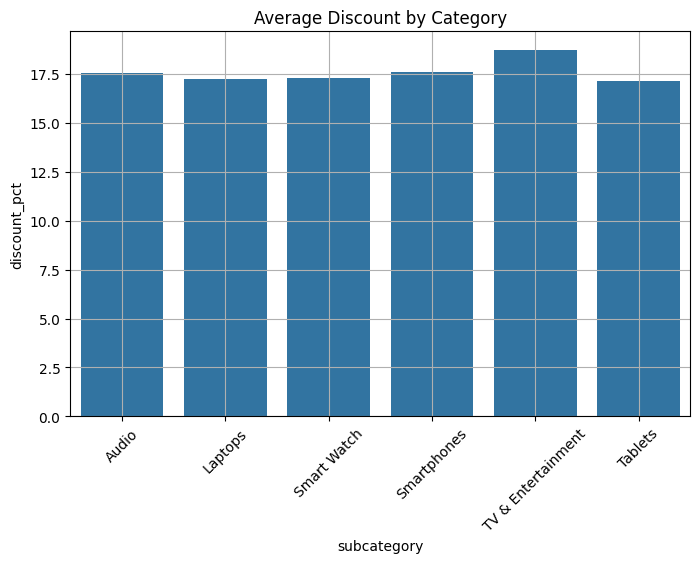

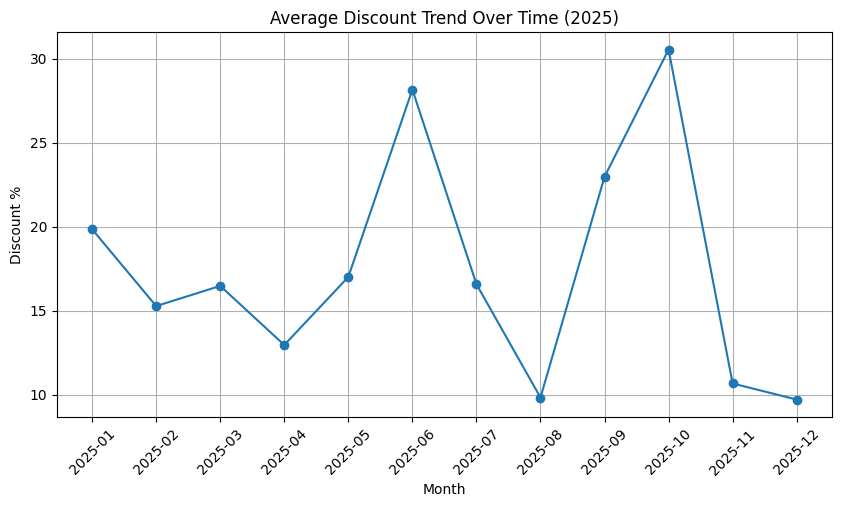

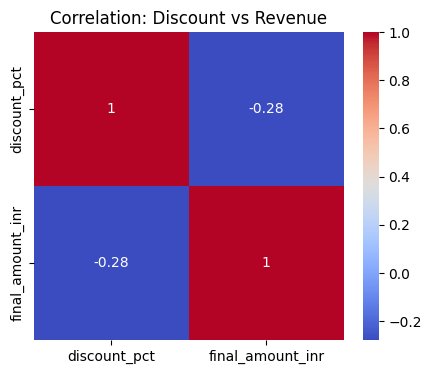

In [ ]:
#Q15: Discount Analysis & Price Sensitivity (2025)


df_2025 = df_2025.copy()

df_2025['order_date'] = pd.to_datetime(df_2025['order_date'])

# Discount %
df_2025['discount_pct'] = (
    (df_2025['original_price_inr'] - df_2025['final_amount_inr']) 
    / df_2025['original_price_inr']
) * 100

# Clean
df_2025 = df_2025[
    (df_2025['discount_pct'] >= 0) &
    (df_2025['discount_pct'] <= 90)  
]

# 2. CREATE DISCOUNT BINS (KEY FIX)

df_2025['discount_bin'] = pd.cut(
    df_2025['discount_pct'],
    bins=[0,10,20,30,40,50,60,70,80,100],
    labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80+']
)

# 3. DISCOUNT vs SALES

sales = df_2025.groupby('discount_bin')['transaction_id'].count().reset_index()

plt.figure(figsize=(8,5))
plt.plot(sales['discount_bin'], sales['transaction_id'], marker='o')
plt.title("Discount Range vs Sales Volume")
plt.xlabel("Discount Range (%)")
plt.ylabel("Number of Orders")
plt.grid()
plt.show()

# 4. DISCOUNT vs REVENUE

revenue = df_2025.groupby('discount_bin')['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.plot(revenue['discount_bin'], revenue['final_amount_inr'], marker='o')
plt.title("Discount Range vs Revenue")
plt.xlabel("Discount Range (%)")
plt.ylabel("Revenue")
plt.grid()
plt.show()

# 5. CATEGORY ANALYSIS

cat_discount = df_2025.groupby('subcategory')[['discount_pct','final_amount_inr']].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=cat_discount, x='subcategory', y='discount_pct')
plt.title("Average Discount by Category")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6. TIME TREND

time_discount = df_2025.groupby(df_2025['order_date'].dt.to_period('M'))['discount_pct'].mean()

time_discount.index = time_discount.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(time_discount.index, time_discount.values, marker='o')
plt.xticks(rotation=45)
plt.title("Average Discount Trend Over Time (2025)")
plt.xlabel("Month")
plt.ylabel("Discount %")
plt.grid()
plt.show()

# 7. CORRELATION

corr = df_2025[['discount_pct','final_amount_inr']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Discount vs Revenue")
plt.show()



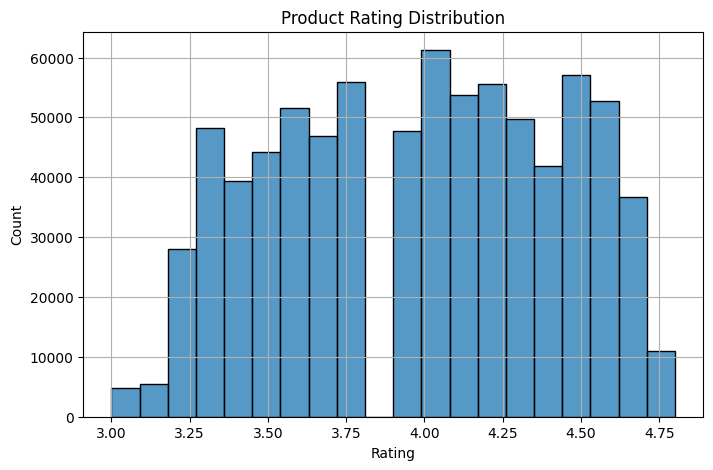

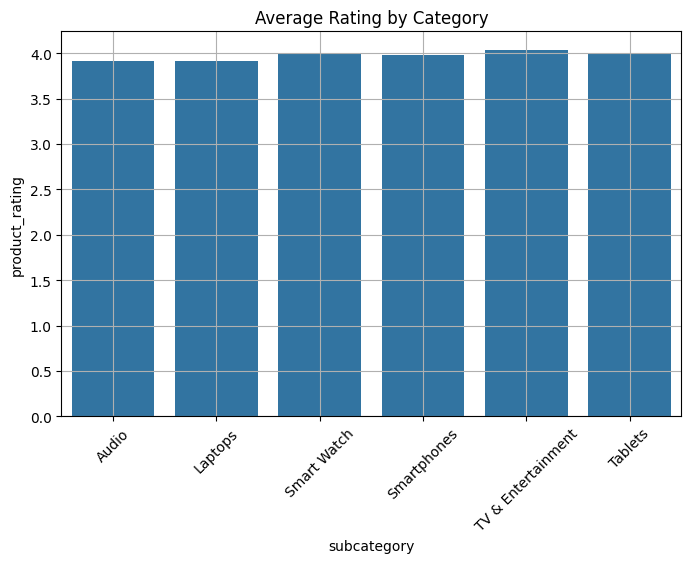

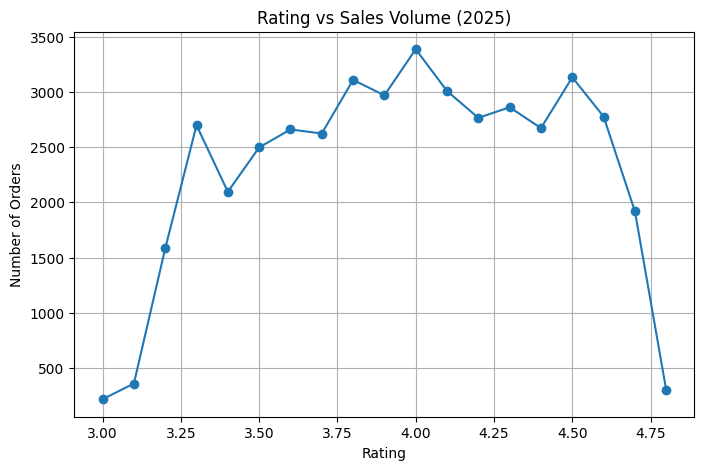

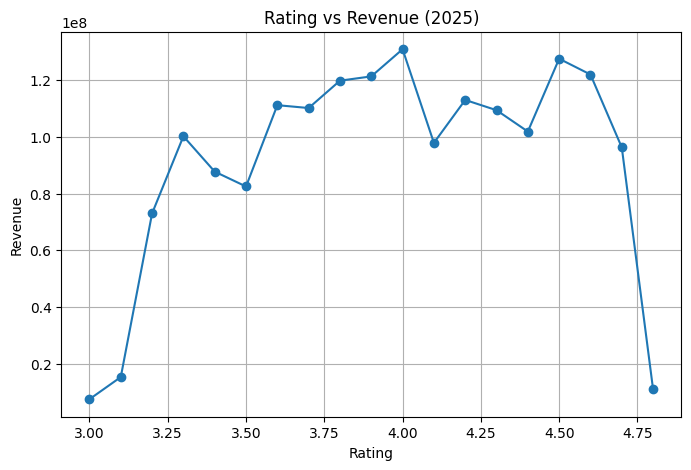

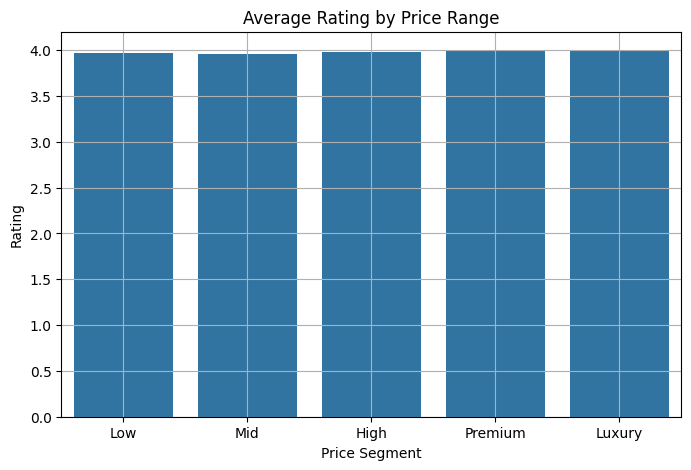

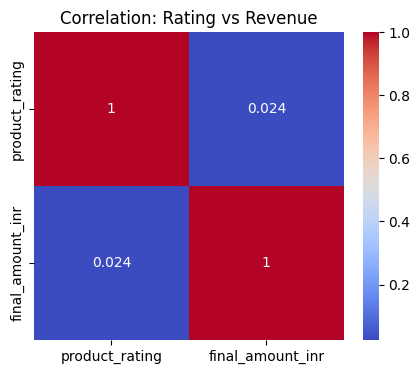

In [ ]:
#Q16: Product Rating Analysis & Customer Feedback (2025)

df['order_date'] = pd.to_datetime(df['order_date'])
df_2025['order_date'] = pd.to_datetime(df_2025['order_date'])

# 2. RATING DISTRIBUTION (2025)

plt.figure(figsize=(8,5))
sns.histplot(df['product_rating'], bins=20)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid()
plt.show()

# 3. AVG RATING BY CATEGORY 

cat_rating = df.groupby('subcategory')['product_rating'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=cat_rating, x='subcategory', y='product_rating')
plt.title("Average Rating by Category")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4. RATING vs SALES (2025)

rating_sales = df_2025.groupby('product_rating')['transaction_id'].count().reset_index()

plt.figure(figsize=(8,5))
plt.plot(rating_sales['product_rating'], rating_sales['transaction_id'], marker='o')
plt.title("Rating vs Sales Volume (2025)")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.grid()
plt.show()

# 5. RATING vs REVENUE (2025)

rating_revenue = df_2025.groupby('product_rating')['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.plot(rating_revenue['product_rating'], rating_revenue['final_amount_inr'], marker='o')
plt.title("Rating vs Revenue (2025)")
plt.xlabel("Rating")
plt.ylabel("Revenue")
plt.grid()
plt.show()

# 6. PRICE RANGE ANALYSIS (2025)

df_2025['price_bin'] = pd.cut(
    df_2025['final_amount_inr'],
    bins=[0,10000,30000,60000,100000,200000],
    labels=['Low','Mid','High','Premium','Luxury']
)

price_rating = df_2025.groupby('price_bin')['product_rating'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=price_rating, x='price_bin', y='product_rating')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Segment")
plt.ylabel("Rating")
plt.grid()
plt.show()

# 7. CORRELATION

corr = df_2025[['product_rating','final_amount_inr']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Rating vs Revenue")
plt.show()

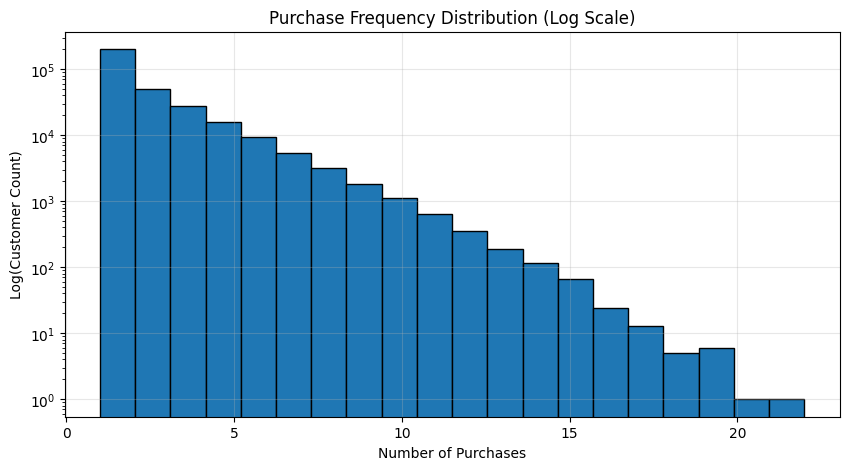

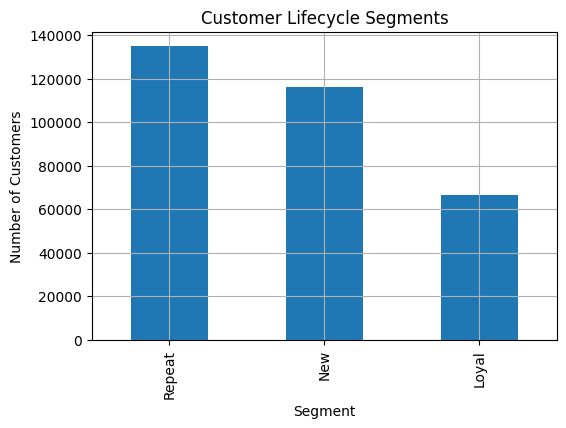

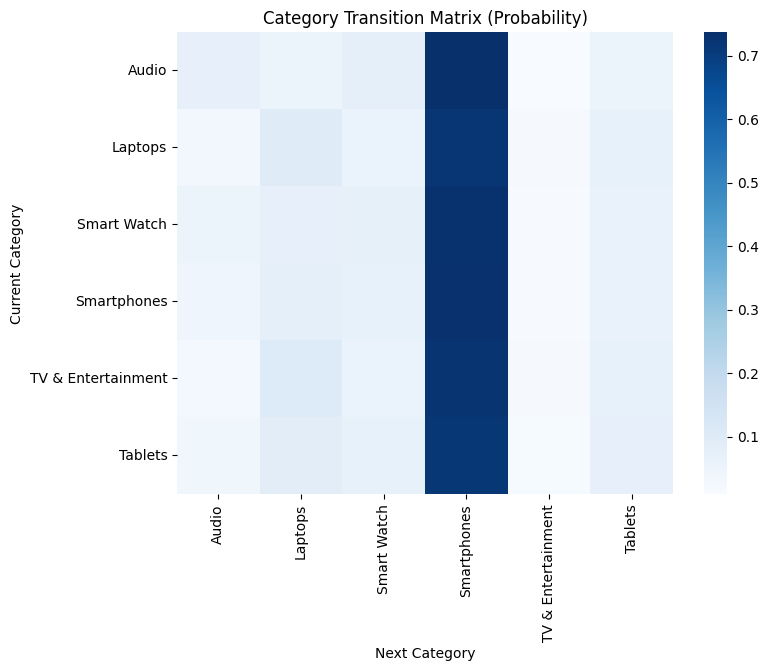

<Figure size 1000x600 with 0 Axes>

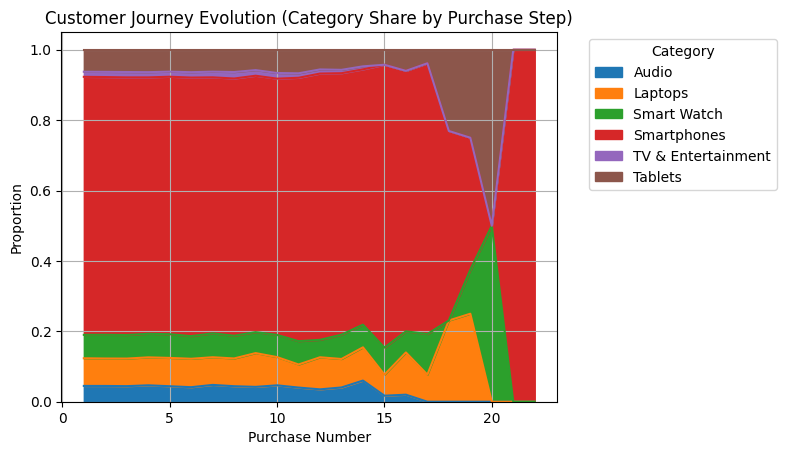

In [30]:
#Q17: Customer Journey Mapping & Evolution Analysis

df1 = df.copy()

df1['order_date'] = pd.to_datetime(df1['order_date'])


df1 = df1.sort_values(by=['customer_id', 'order_date'])

# 2. PURCHASE FREQUENCY

purchase_freq = df1.groupby('customer_id')['transaction_id'].count()

plt.figure(figsize=(10,5))

plt.hist(purchase_freq,bins=20,edgecolor='black')

plt.yscale('log')

plt.title("Purchase Frequency Distribution (Log Scale)")
plt.xlabel("Number of Purchases")
plt.ylabel("Log(Customer Count)")

plt.grid(alpha=0.3)

plt.show()

# 3. CUSTOMER SEGMENT (LIFECYCLE)

def segment_customer(x):
    if x == 1:
        return "New"
    elif x <= 3:
        return "Repeat"
    else:
        return "Loyal"

customer_segment = purchase_freq.apply(segment_customer).reset_index()
customer_segment.columns = ['customer_id', 'segment']

segment_counts = customer_segment['segment'].value_counts()

plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar')
plt.title("Customer Lifecycle Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.grid()
plt.show()

# 4. CATEGORY TRANSITIONS

df1['next_category'] = df1.groupby('customer_id')['subcategory'].shift(-1)

transitions = df1.dropna(subset=['next_category'])

transition_matrix = pd.crosstab(
    transitions['subcategory'],
    transitions['next_category']
)

# Normalize (probabilities)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(transition_matrix, cmap='Blues')
plt.title("Category Transition Matrix (Probability)")
plt.xlabel("Next Category")
plt.ylabel("Current Category")
plt.show()

# 5. CUSTOMER EVOLUTION (STEP-WISE)

df1['purchase_number'] = df1.groupby('customer_id').cumcount() + 1

evolution = df1.groupby('purchase_number')['subcategory'].value_counts().unstack().fillna(0)

evolution_pct = evolution.div(evolution.sum(axis=1), axis=0)

plt.figure(figsize=(10,6))
evolution_pct.plot(kind='area', stacked=True)
plt.title("Customer Journey Evolution (Category Share by Purchase Step)")
plt.xlabel("Purchase Number")
plt.ylabel("Proportion")
plt.legend(title="Category", bbox_to_anchor=(1.05,1))
plt.grid()
plt.show()

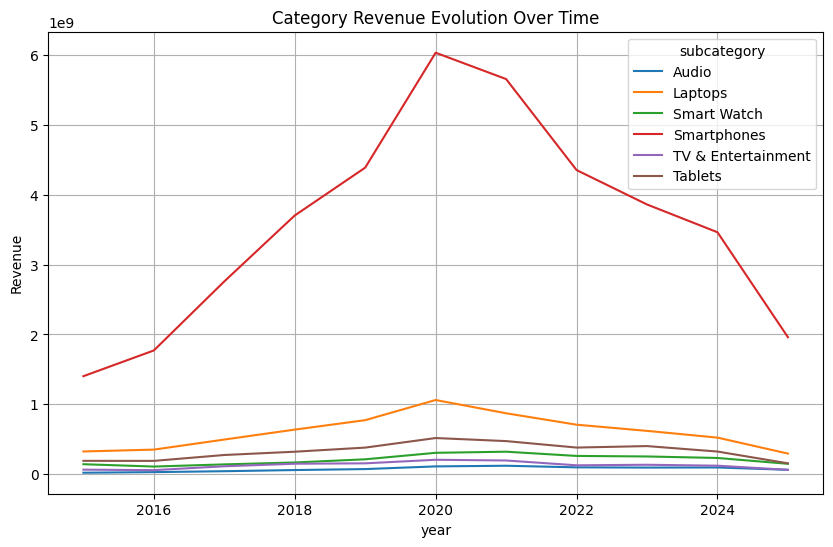

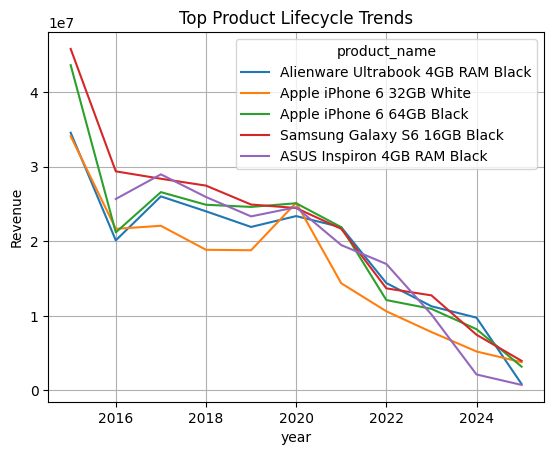

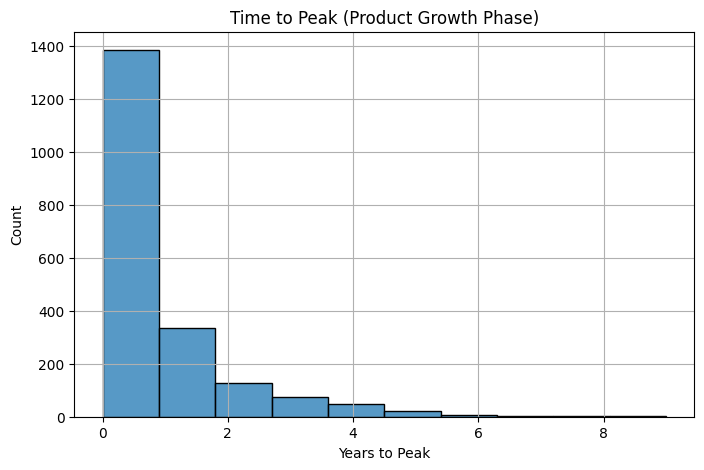

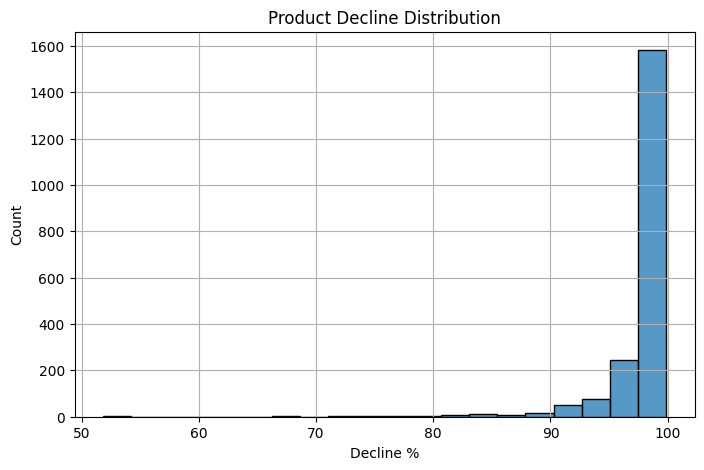

In [31]:
#Q18: Product Lifecycle Analysis & Evolution Trends
df1 = df.copy()

df1['order_date'] = pd.to_datetime(df1['order_date'])
df1['year'] = df1['order_date'].dt.year

# 2. CATEGORY EVOLUTION

cat_trend = df1.groupby(['year','subcategory'])['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=cat_trend, x='year', y='final_amount_inr', hue='subcategory')
plt.title("Category Revenue Evolution Over Time")
plt.ylabel("Revenue")
plt.grid()
plt.show()

# 3. PRODUCT LIFECYCLE (TOP PRODUCTS)

top_products = df1.groupby('product_name')['final_amount_inr'].sum().nlargest(5).index
prod_trend = df1[df1['product_name'].isin(top_products)]
prod_trend = prod_trend.groupby(['year','product_name'])['final_amount_inr'].sum().reset_index()
sns.lineplot(data=prod_trend, x='year', y='final_amount_inr', hue='product_name')

plt.title("Top Product Lifecycle Trends")
plt.ylabel("Revenue")
plt.grid()
plt.show()

# 4. TIME TO PEAK

product_year = df1.groupby(['product_id','year'])['final_amount_inr'].sum().reset_index()

peak_year = product_year.loc[product_year.groupby('product_id')['final_amount_inr'].idxmax()]
launch_year = df1.groupby('product_id')['year'].min().reset_index()

lifecycle = launch_year.merge(peak_year[['product_id','year']], on='product_id')
lifecycle.columns = ['product_id','launch_year','peak_year']

lifecycle['time_to_peak'] = lifecycle['peak_year'] - lifecycle['launch_year']

plt.figure(figsize=(8,5))
sns.histplot(lifecycle['time_to_peak'], bins=10)
plt.title("Time to Peak (Product Growth Phase)")
plt.xlabel("Years to Peak")
plt.grid()
plt.show()

# 5. DECLINE ANALYSIS

peak_sales = product_year.groupby('product_id')['final_amount_inr'].max()

last_year_sales = df1.sort_values('year').groupby('product_id').tail(1)
recent_sales = last_year_sales.set_index('product_id')['final_amount_inr']

decline = pd.DataFrame({
    'peak_sales': peak_sales,
    'recent_sales': recent_sales
}).dropna()

decline['decline_pct'] = (
    (decline['peak_sales'] - decline['recent_sales']) 
    / decline['peak_sales']
) * 100

plt.figure(figsize=(8,5))
sns.histplot(decline['decline_pct'], bins=20)
plt.title("Product Decline Distribution")
plt.xlabel("Decline %")
plt.grid()
plt.show()

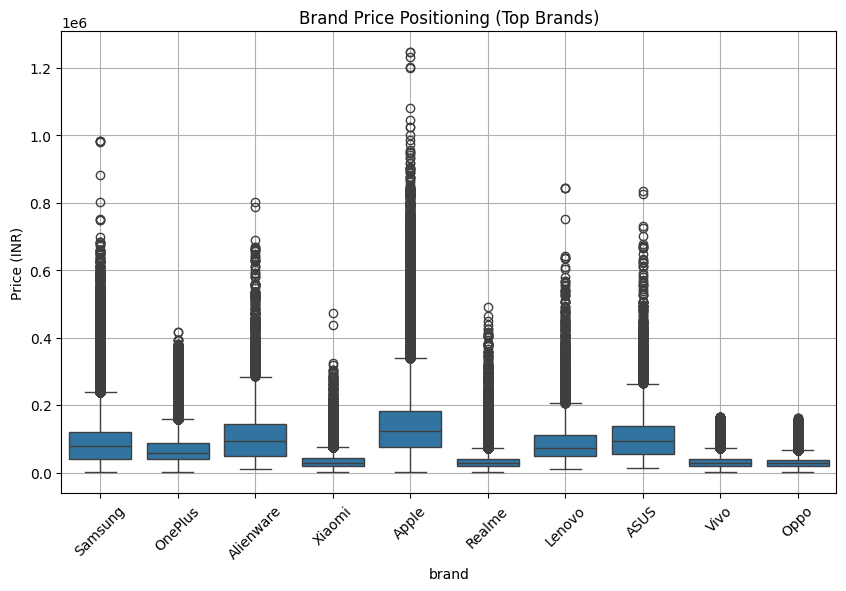

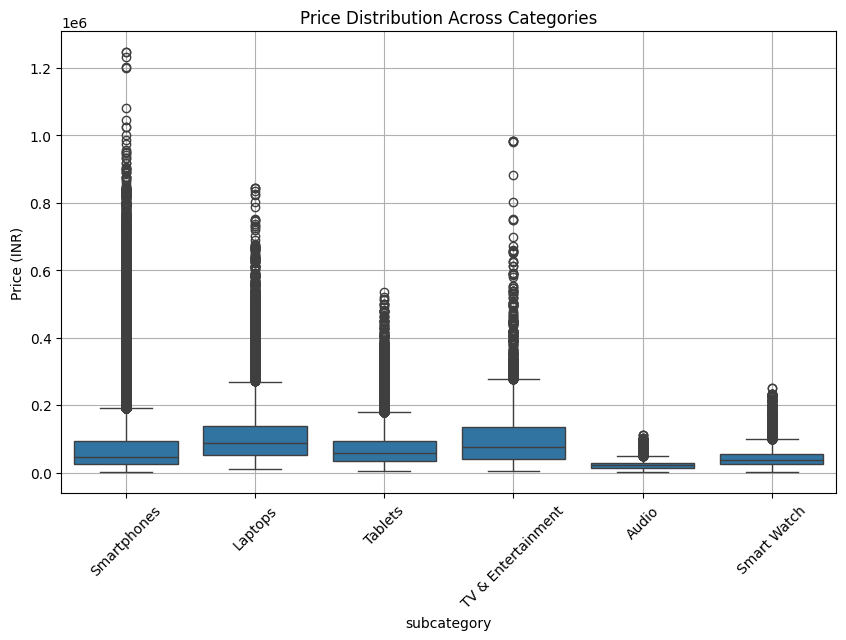

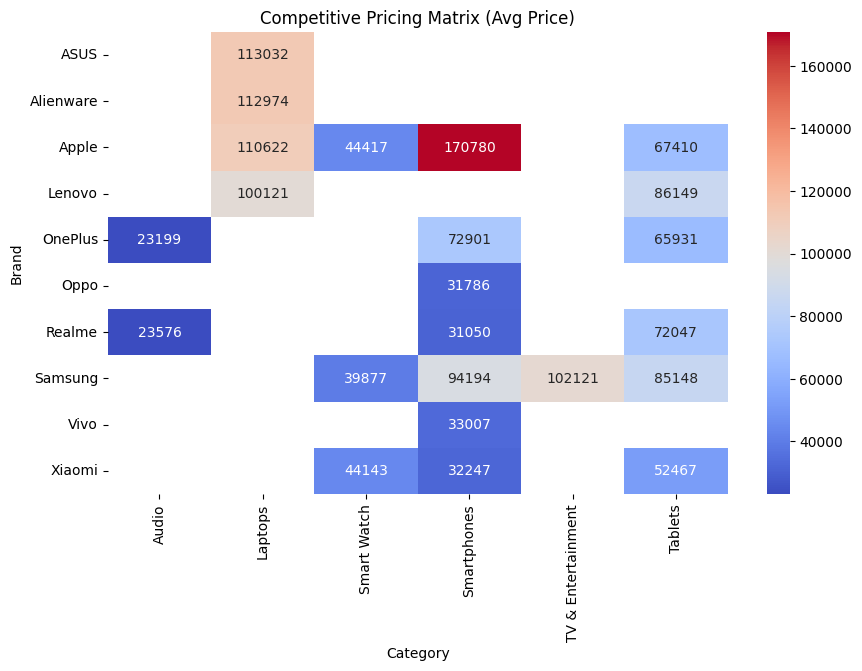

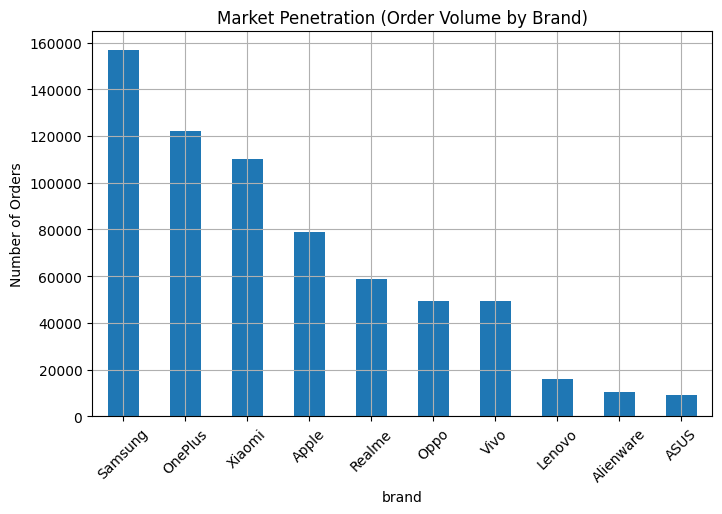

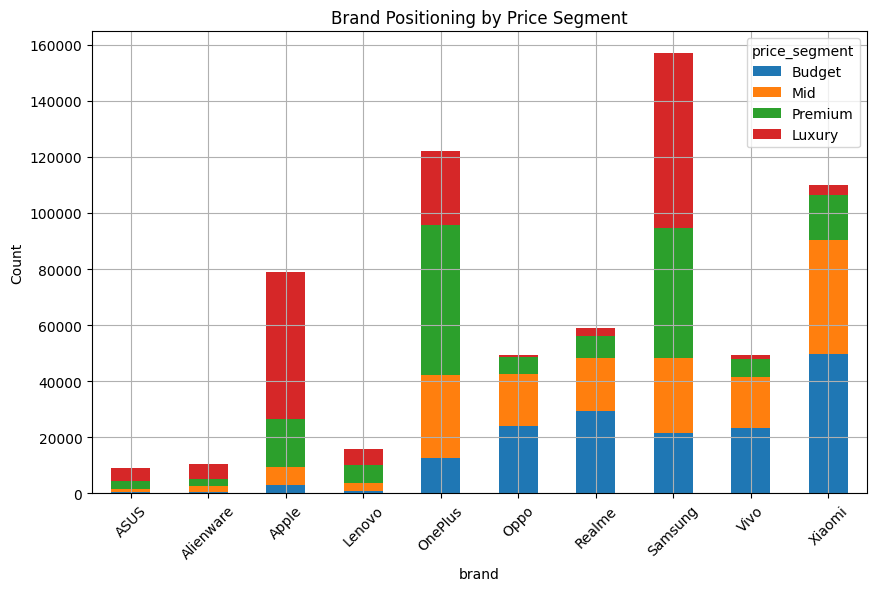

In [32]:
#Q19: Competitive Pricing Analysis & Brand Positioning (2025)
df1 = df.copy()

# 2. BRAND PRICE POSITIONING

top_brands = df1.groupby('brand')['final_amount_inr'].sum().nlargest(10).index
df_top = df1[df1['brand'].isin(top_brands)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_top, x='brand', y='final_amount_inr')
plt.xticks(rotation=45)
plt.title("Brand Price Positioning (Top Brands)")
plt.ylabel("Price (INR)")
plt.grid()
plt.show()

# 3. CATEGORY-WISE PRICE DISTRIBUTION

plt.figure(figsize=(10,6))
sns.boxplot(data=df_top, x='subcategory', y='final_amount_inr')
plt.xticks(rotation=45)
plt.title("Price Distribution Across Categories")
plt.ylabel("Price (INR)")
plt.grid()
plt.show()

# 4. COMPETITIVE MATRIX (BRAND vs CATEGORY)

matrix = df_top.groupby(['brand','subcategory'])['final_amount_inr'].mean().reset_index()

pivot = matrix.pivot(index='brand', columns='subcategory', values='final_amount_inr')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Competitive Pricing Matrix (Avg Price)")
plt.ylabel("Brand")
plt.xlabel("Category")
plt.show()

# 5. MARKET PENETRATION (VOLUME SHARE)

volume = df_top.groupby('brand')['transaction_id'].count().sort_values(ascending=False)

volume.plot(kind='bar', figsize=(8,5))
plt.title("Market Penetration (Order Volume by Brand)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6. PRICE SEGMENT CLASSIFICATION

df_top['price_segment'] = pd.qcut(df_top['final_amount_inr'], 4, labels=['Budget','Mid','Premium','Luxury'])

segment = df_top.groupby(['brand','price_segment']).size().unstack().fillna(0)

segment.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Brand Positioning by Price Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [33]:
df.columns

Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name', 'category', 'subcategory', 'brand',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible',
       'product_rating', 'base_price_2015_x', 'base_price_2015_y', 'year',
       'acq_year'],
      dtype='str')

In [34]:
df['year'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype=int32)

In [ ]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce',
    dayfirst=True
)

df['year'] = df['order_date'].dt.year

C:\Users\Admin\AppData\Local\Temp\ipykernel_4072\1696132252.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(


In [ ]:
print(df['year'].value_counts().sort_index())

year
2015    33000
2016    38321
2017    53528
2018    68939
2019    84381
2020    99588
2021    95833
2022    91971
2023    88209
2024    84512
2025    53662
Name: count, dtype: int64


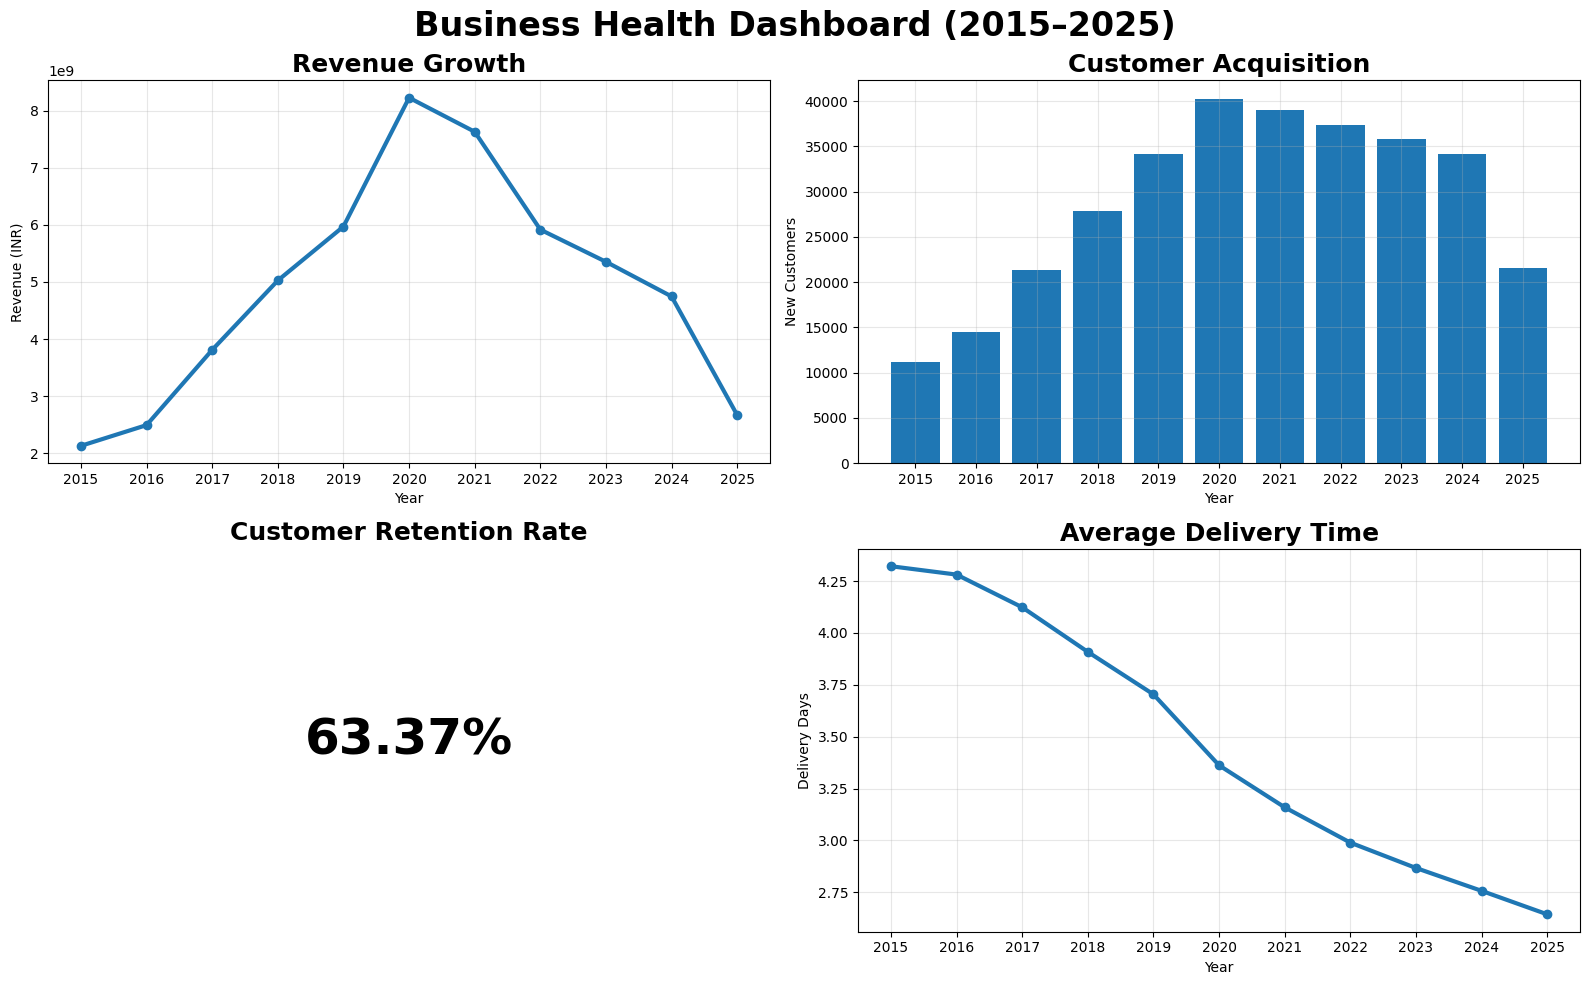

In [35]:
# Q20: BUSINESS HEALTH DASHBOARD (2015–2025)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA PREPARATION

df1 = df.copy()

# Convert order date properly
df1['order_date'] = pd.to_datetime(
    df1['order_date'],
    errors='coerce',
    dayfirst=True
)

# Remove invalid dates
df1 = df1.dropna(subset=['order_date'])

# Extract year and month
df1['year'] = df1['order_date'].dt.year

df1['month'] = df1['order_date'].dt.to_period('M')

# 2. REVENUE GROWTH

rev = (
    df1.groupby('year')['final_amount_inr']
    .sum()
    .sort_index()
)

# 3. CUSTOMER ACQUISITION

# First purchase date
df1['first_purchase'] = (
    df1.groupby('customer_id')['order_date']
    .transform('min')
)

# Acquisition year
df1['acq_year'] = (
    df1['first_purchase']
    .dt.year
)

# New customers per year
acq = (
    df1.groupby('acq_year')['customer_id']
    .nunique()
    .sort_index()
)

# 4. CUSTOMER RETENTION RATE

cust_orders = (
    df1.groupby('customer_id')['transaction_id']
    .count()
)

repeat_rate = (
    (cust_orders > 1).mean()
) * 100

# 5. OPERATIONAL EFFICIENCY

if 'delivery_days' in df1.columns:

    delivery = (
        df1.groupby('year')['delivery_days']
        .mean()
        .sort_index()
    )

else:

    delivery = None

# 6. DASHBOARD

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

fig.suptitle(
    "Business Health Dashboard (2015–2025)",
    fontsize=24,
    fontweight='bold'
)

# REVENUE GROWTH

axes[0,0].plot(
    rev.index,
    rev.values,
    marker='o',
    linewidth=3
)

axes[0,0].set_title(
    "Revenue Growth",
    fontsize=18,
    fontweight='bold'
)

axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Revenue (INR)")

axes[0,0].set_xticks(rev.index)

axes[0,0].grid(alpha=0.3)

# CUSTOMER ACQUISITION

axes[0,1].bar(
    acq.index,
    acq.values
)

axes[0,1].set_title(
    "Customer Acquisition",
    fontsize=18,
    fontweight='bold'
)

axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("New Customers")

axes[0,1].set_xticks(acq.index)

axes[0,1].grid(alpha=0.3)

# CUSTOMER RETENTION

axes[1,0].text(
    0.5,
    0.5,
    f"{repeat_rate:.2f}%",
    ha='center',
    va='center',
    fontsize=36,
    fontweight='bold'
)

axes[1,0].set_title(
    "Customer Retention Rate",
    fontsize=18,
    fontweight='bold'
)

axes[1,0].axis('off')

# DELIVERY EFFICIENCY

if delivery is not None:

    axes[1,1].plot(
        delivery.index,
        delivery.values,
        marker='o',
        linewidth=3
    )

    axes[1,1].set_title(
        "Average Delivery Time",
        fontsize=18,
        fontweight='bold'
    )

    axes[1,1].set_xlabel("Year")
    axes[1,1].set_ylabel("Delivery Days")

    axes[1,1].set_xticks(delivery.index)

    axes[1,1].grid(alpha=0.3)

else:

    axes[1,1].text(
        0.5,
        0.5,
        "No Delivery Data",
        ha='center',
        va='center',
        fontsize=18
    )

    axes[1,1].set_title(
        "Average Delivery Time",
        fontsize=18,
        fontweight='bold'
    )

    axes[1,1].axis('off')

plt.tight_layout()

plt.show()

In [36]:
df.columns

Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name', 'category', 'subcategory', 'brand',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible',
       'product_rating', 'base_price_2015_x', 'base_price_2015_y', 'year',
       'acq_year'],
      dtype='str')

In [ ]:


df['order_month'] = df['order_month'].astype(str)



In [ ]:
df['delivery_days'] = df['delivery_days'].astype(int)

In [ ]:


print(df.shape)
df.info()
df.head()



(791944, 40)
<class 'pandas.DataFrame'>
RangeIndex: 791944 entries, 0 to 791943
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          791944 non-null  str           
 1   order_date              791944 non-null  datetime64[us]
 2   customer_id             791944 non-null  str           
 3   product_id              791944 non-null  str           
 4   product_name            791944 non-null  str           
 5   category                791944 non-null  str           
 6   subcategory             791944 non-null  str           
 7   brand                   791944 non-null  str           
 8   original_price_inr      791944 non-null  float64       
 9   discount_percent        791944 non-null  float64       
 10  discounted_price_inr    791944 non-null  float64       
 11  quantity                791944 non-null  int64         
 12  subtotal_inr            7919

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,order_quarter,product_weight_kg,is_prime_eligible,product_rating,base_price_2015_x,base_price_2015_y,year,month,first_purchase,acq_year
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,Electronics,Smartphones,Samsung,123614.29,27.91,...,1,0.19,True,4.7,NaN,NaN,2015,2015-01,2015-01-25,2015
1,TXN_2015_00000002,2015-05-01,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,1,0.20,True,4.1,NaN,NaN,2015,2015-05,2015-02-08,2015
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,Electronics,Smartphones,Samsung,97644.25,46.93,...,1,0.17,True,3.3,NaN,NaN,2015,2015-01,2015-01-12,2015
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,Electronics,Smartphones,Motorola,46458.94,0.00,...,1,0.22,True,3.5,NaN,NaN,2015,2015-01,2015-01-28,2015
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,1,0.20,True,4.1,NaN,NaN,2015,2015-01,2015-01-31,2015


In [ ]:

drop_cols = ['year','base_price_2015_x','base_price_2015_y','month','first_purchase','acq_year']

df = df.drop(columns=drop_cols)



In [ ]:

print(df.dtypes)



transaction_id                       str
order_date                datetime64[us]
customer_id                          str
product_id                           str
product_name                         str
category                             str
subcategory                          str
brand                                str
original_price_inr               float64
discount_percent                 float64
discounted_price_inr             float64
quantity                           int64
subtotal_inr                     float64
delivery_charges                 float64
final_amount_inr                 float64
customer_city                        str
customer_state                       str
customer_tier                        str
customer_spending_tier               str
customer_age_group                   str
payment_method                       str
delivery_days                      int64
delivery_type                        str
is_prime_member                     bool
is_festival_sale